In [2]:
from pathlib import Path
cwd = Path.cwd()
print("Current working directory:", cwd.resolve())

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation


## Model with equal time frames

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.linalg import eig
from skfda import FDataGrid
from skfda.preprocessing.dim_reduction import FPCA
from skfda.representation.basis import BSpline
from typing import Optional, Dict, Tuple
sns.set_theme(style="whitegrid", font_scale=1.1)

class FPCA_MSM:
    """
    MSM for gait stability using FPCA + K-means:
    each window → functional representation → FPCA → K-means → Stable/Marginal/Unstable.
    """
    def __init__(self,
                 patient_id: str,
                 n_states: int = 3,
                 window_size: int = 100,
                 window_overlap: float = 0.0,
                 n_components: int = 3,
                 n_basis: int = 15):
        self.patient_id        = patient_id
        self.n_states          = n_states
        self.window_size       = window_size
        self.window_overlap    = window_overlap
        self.n_components      = n_components
        self.n_basis           = n_basis
        self.scaler            = StandardScaler()
        self.metadata          = {}
        self.fpca              = None
        self.kmeans            = None
        self.transition_matrix = None
        self.stationary_dist   = None
        self.state_labels      = {0:"Stable", 1:"Marginally Stable", 2:"Unstable"}
        self.metrics_history   = None
        self.fdata             = None
        self.fpca_scores       = None

    def compute_windowed_functional_data(self, signal: np.ndarray, fs: float) -> FDataGrid:
        """Convert windowed time series into functional data objects."""
        step = int(self.window_size * (1 - self.window_overlap))
        n_windows = (len(signal) - self.window_size) // step + 1
        
        # Collect windows
        windows = []
        time_points = []
        for i in range(n_windows):
            start = i * step
            window = signal[start:start + self.window_size]
            windows.append(window)
            time_points.append(start / fs)
        
        # Create functional data object
        # Time grid within each window (normalized to [0, 1])
        grid_points = np.linspace(0, 1, self.window_size)
        
        # Convert to FDataGrid
        self.fdata = FDataGrid(
            data_matrix=np.array(windows),
            grid_points=grid_points
        )
        
        # Store metadata
        self.metrics_history = pd.DataFrame({
            'window_idx': range(n_windows),
            'time': time_points
        })
        
        return self.fdata

    def apply_fpca(self) -> np.ndarray:
        """Apply Functional PCA to extract principal components."""
        try:
            # Try to smooth the functional data using B-spline basis
            basis = BSpline(n_basis=self.n_basis, domain_range=(0, 1))
            smooth_fdata = self.fdata.to_basis(basis)
            
            # Apply FPCA to smoothed data
            self.fpca = FPCA(n_components=self.n_components)
            self.fpca_scores = self.fpca.fit_transform(smooth_fdata)
        except:
            # If smoothing fails, apply FPCA directly to the discrete data
            print("Note: B-spline smoothing failed, using direct FPCA on discrete data")
            self.fpca = FPCA(n_components=self.n_components)
            self.fpca_scores = self.fpca.fit_transform(self.fdata)
        
        # Add FPCA scores to metrics history
        for i in range(self.n_components):
            self.metrics_history[f'fpca_{i}'] = self.fpca_scores[:, i]
        
        return self.fpca_scores

    def identify_stability_states(self) -> np.ndarray:
        """Apply K-means clustering to FPCA scores to identify states."""
        # Standardize FPCA scores
        X = self.scaler.fit_transform(self.fpca_scores)
        
        # Apply K-means
        self.kmeans = KMeans(n_clusters=self.n_states, random_state=42)
        raw_states = self.kmeans.fit_predict(X)
        
        # Order states by distance from origin (stability proxy)
        # Assumption: more stable states have smaller variations in FPCA space
        cluster_centers = self.kmeans.cluster_centers_
        norms = np.linalg.norm(cluster_centers, axis=1)
        order = np.argsort(norms)
        
        # Remap states to ensure 0=stable, 2=unstable
        state_mapping = {old: new for new, old in enumerate(order)}
        states = np.array([state_mapping[s] for s in raw_states])
        
        self.metrics_history['state'] = states
        return states

    def compute_transition_matrix(self, states: np.ndarray) -> np.ndarray:
        """Compute state transition probabilities."""
        T = np.zeros((self.n_states, self.n_states))
        for a, b in zip(states[:-1], states[1:]):
            T[a, b] += 1
        
        # Normalize rows
        row_sums = T.sum(axis=1)
        row_sums[row_sums == 0] = 1  # Avoid division by zero
        T = T / row_sums[:, None]
        
        self.transition_matrix = T
        return T

    def compute_stationary_distribution(self) -> np.ndarray:
        """Compute stationary distribution of the Markov chain."""
        vals, vecs = eig(self.transition_matrix.T)
        idx = np.argmin(np.abs(vals - 1))
        pi = np.real(vecs[:, idx])
        pi = pi / pi.sum()
        self.stationary_dist = np.abs(pi)
        return self.stationary_dist

    def compute_mean_dwell_times(self) -> np.ndarray:
        """Compute mean dwell time in each state."""
        τ = np.zeros(self.n_states)
        for i in range(self.n_states):
            p = self.transition_matrix[i, i]
            τ[i] = np.inf if p >= 1 else 1 / (1 - p)
        return τ

    def compute_stability_metrics(self) -> dict:
        """Compute overall stability metrics."""
        df = self.metrics_history
        out = {'patient_id': self.patient_id}
        
        # State fractions
        for i in range(self.n_states):
            out[f'frac_state_{i}'] = (df.state == i).mean()
        
        # Mean FPCA scores per state
        for i in range(self.n_states):
            state_data = df[df.state == i]
            for j in range(self.n_components):
                out[f'mean_fpca_{j}_state_{i}'] = state_data[f'fpca_{j}'].mean()
        
        return out

    def visualize_patient_analysis(self):
        """2×2 summary figure with FPCA results and transitions."""
        df = self.metrics_history.copy()
        names = list(self.state_labels.values())
        colors = sns.color_palette(n_colors=self.n_states)
        palette = dict(zip(names, colors))
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # 1) FPCA explained variance
        if self.fpca is not None:
            explained_var = self.fpca.explained_variance_ratio_
            pc_labels = [f'PC{i+1}' for i in range(len(explained_var))]
            axes[0, 0].bar(pc_labels, explained_var, color='skyblue')
            axes[0, 0].set_title('FPCA Explained Variance Ratio')
            axes[0, 0].set_ylabel('Variance Explained')
            for i, v in enumerate(explained_var):
                axes[0, 0].text(i, v + 0.01, f'{v:.1%}', ha='center')
        
        # 2) Transition matrix heatmap
        sns.heatmap(self.transition_matrix,
                    annot=True, fmt=".2f",
                    xticklabels=names, yticklabels=names,
                    cmap="Blues", ax=axes[0, 1])
        axes[0, 1].set_title("Transition Probabilities")
        
        # 3) FPCA scores scatter (first 2 PCs)
        if self.n_components >= 2:
            for i, (state, name) in enumerate(self.state_labels.items()):
                mask = df.state == state
                axes[1, 0].scatter(df.loc[mask, 'fpca_0'], 
                                 df.loc[mask, 'fpca_1'],
                                 label=name, color=colors[i], alpha=0.6)
            axes[1, 0].set_xlabel('FPCA Component 1')
            axes[1, 0].set_ylabel('FPCA Component 2')
            axes[1, 0].set_title('State Distribution in FPCA Space')
            axes[1, 0].legend()
        
        # 4) Stationary distribution
        axes[1, 1].bar(names, self.stationary_dist, color=colors)
        axes[1, 1].set_ylim(0, 1)
        axes[1, 1].set_title("Stationary Distribution")
        for i, v in enumerate(self.stationary_dist):
            axes[1, 1].text(i, v + 0.02, f"{v:.1%}", ha='center')
        
        plt.tight_layout()
        plt.show()

    def visualize_functional_modes(self):
        """Visualize the functional principal components."""
        if self.fpca is None:
            return
        
        fig, axes = plt.subplots(1, min(3, self.n_components), 
                                figsize=(5*min(3, self.n_components), 4))
        
        if self.n_components == 1:
            axes = [axes]
        
        # Create evaluation grid
        grid = np.linspace(0, 1, 100)
        
        # Get mean function and components
        mean_func = self.fpca.mean_
        
        # Evaluate mean function on grid
        mean_values = mean_func(grid).flatten()
        
        for i in range(min(3, self.n_components)):
            # Get principal component
            pc = self.fpca.components_[i]
            pc_values = pc(grid).flatten()
            
            # Plot mean ± PC
            axes[i].plot(grid, mean_values, 'k-', 
                        label='Mean', linewidth=2)
            axes[i].plot(grid, mean_values + 2*np.sqrt(self.fpca.explained_variance_[i])*pc_values, 
                        'b--', label='+2 SD', alpha=0.7)
            axes[i].plot(grid, mean_values - 2*np.sqrt(self.fpca.explained_variance_[i])*pc_values, 
                        'r--', label='-2 SD', alpha=0.7)
            axes[i].set_title(f'PC{i+1} ({self.fpca.explained_variance_ratio_[i]:.1%} var)')
            axes[i].set_xlabel('Normalized Time')
            axes[i].legend()
        
        plt.tight_layout()
        plt.show()

    def fit(self, signal: np.ndarray, fs: float) -> 'FPCA_MSM':
        """Complete pipeline: signal → functional data → FPCA → clustering → MSM."""
        print(f"Processing patient {self.patient_id}...")
        
        # 1. Create functional data from windows
        print("Creating functional data representation...")
        self.compute_windowed_functional_data(signal, fs)
        
        # 2. Apply FPCA
        print(f"Applying FPCA with {self.n_components} components...")
        self.apply_fpca()
        
        # 3. Identify states via K-means
        print("Identifying stability states via K-means...")
        states = self.identify_stability_states()
        
        # 4. Build Markov model
        print("Computing transition matrix...")
        self.compute_transition_matrix(states)
        
        # 5. Compute stationary distribution
        print("Computing stationary distribution...")
        self.compute_stationary_distribution()
        
        # 6. Compute metrics
        metrics = self.compute_stability_metrics()
        print(f"\nStability metrics for {self.patient_id}:")
        for key, value in metrics.items():
            if key != 'patient_id':
                print(f"  {key}: {value:.3f}")
        
        return self
    

Single-stride window = 113 samples (~1.13s)
Processing patient 04_PWS...
Creating functional data representation...
Applying FPCA with 3 components...
Identifying stability states via K-means...
Computing transition matrix...
Computing stationary distribution...

Stability metrics for 04_PWS:
  frac_state_0: 0.508
  frac_state_1: 0.279
  frac_state_2: 0.213
  mean_fpca_0_state_0: 13.503
  mean_fpca_1_state_0: 1.702
  mean_fpca_2_state_0: 0.731
  mean_fpca_0_state_1: -7.974
  mean_fpca_1_state_1: -8.700
  mean_fpca_2_state_1: -2.521
  mean_fpca_0_state_2: -21.772
  mean_fpca_1_state_2: 7.318
  mean_fpca_2_state_2: 1.554


C:\Users\Natascha\AppData\Local\Temp\ipykernel_31580\3922827744.py:79: DeprecationWarning: The BSpline class is deprecated. Use BSplineBasis instead.
  basis = BSpline(n_basis=self.n_basis, domain_range=(0, 1))


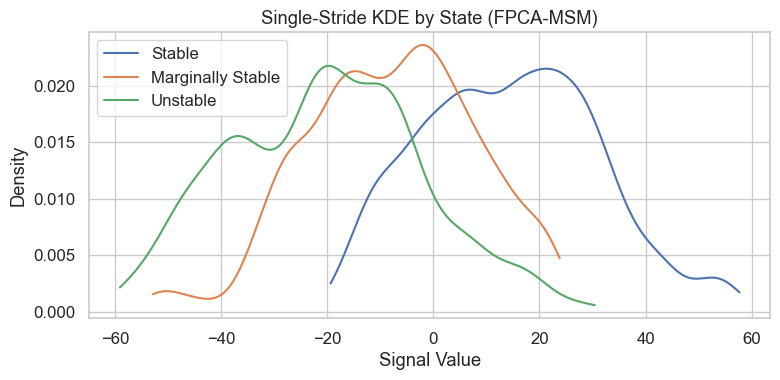

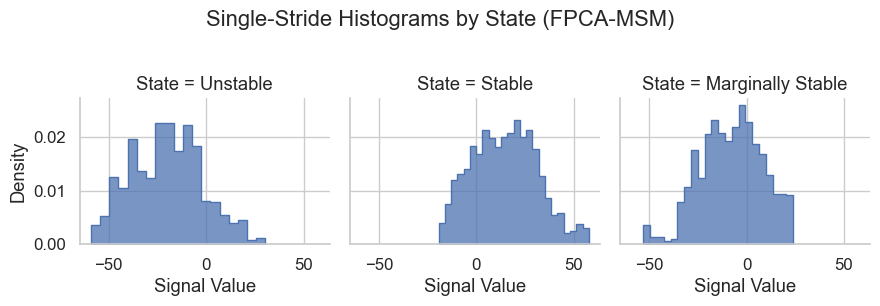

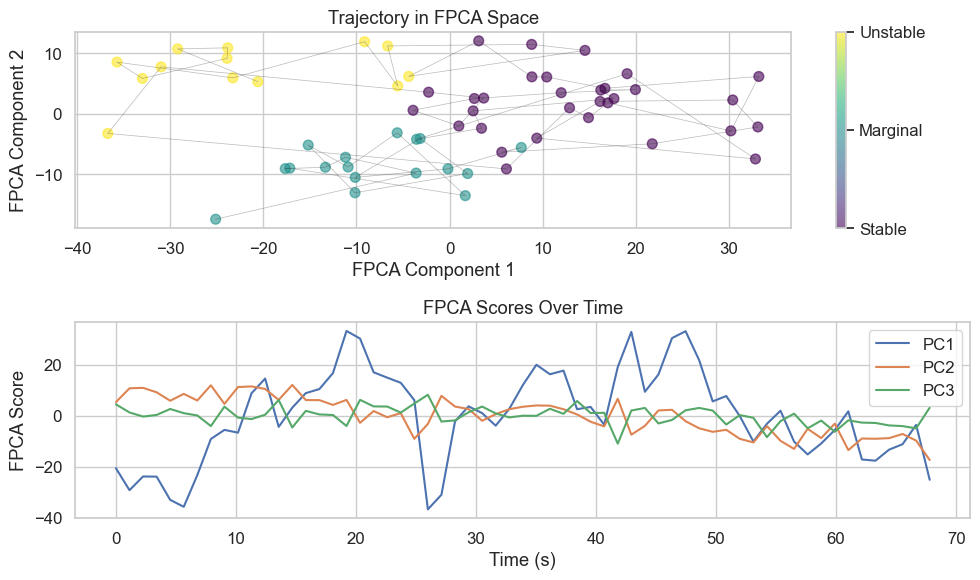

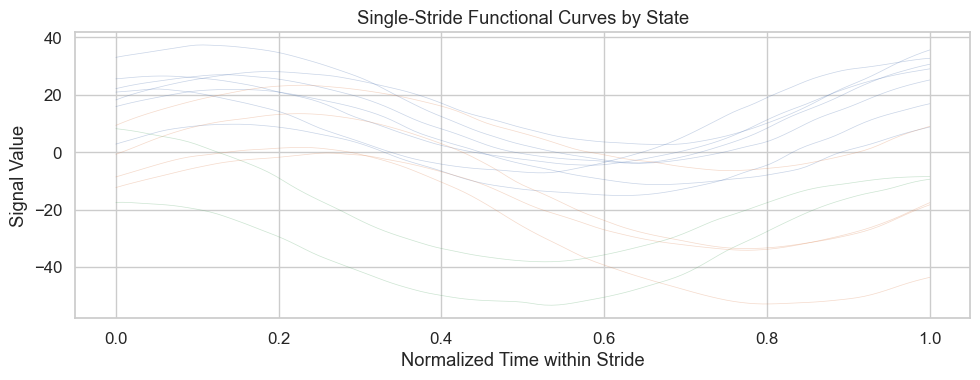

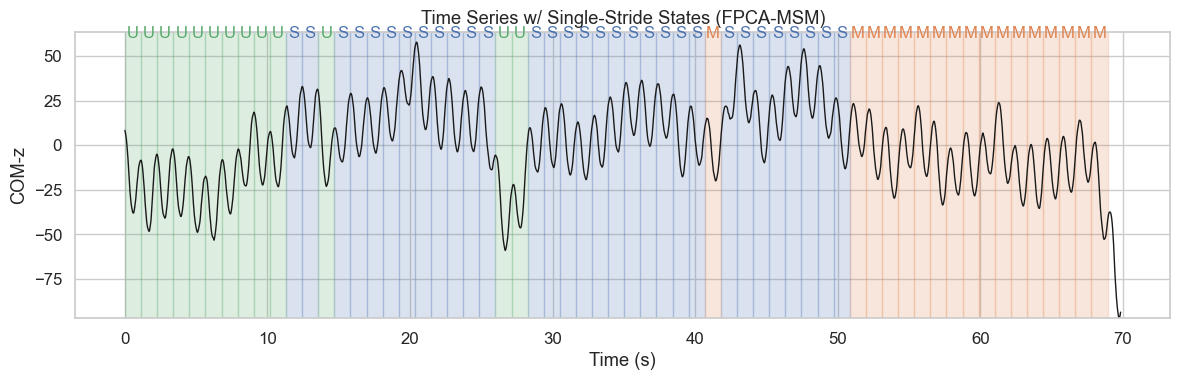


FPCA-MSM RESULTS

Transition Matrix T:
[[0.871 0.065 0.065]
 [0.062 0.938 0.   ]
 [0.231 0.    0.769]]

Stationary Distribution Π:
[0.433 0.447 0.121]

Mean Dwell Times τ (windows):
[ 7.75  16.     4.333]

Fraction of time in each state:
  frac_state_0: 0.508
  frac_state_1: 0.279
  frac_state_2: 0.213

FPCA Explained Variance Ratio:
  PC1: 82.0%
  PC2: 14.2%
  PC3: 3.3%

Generating summary visualizations...


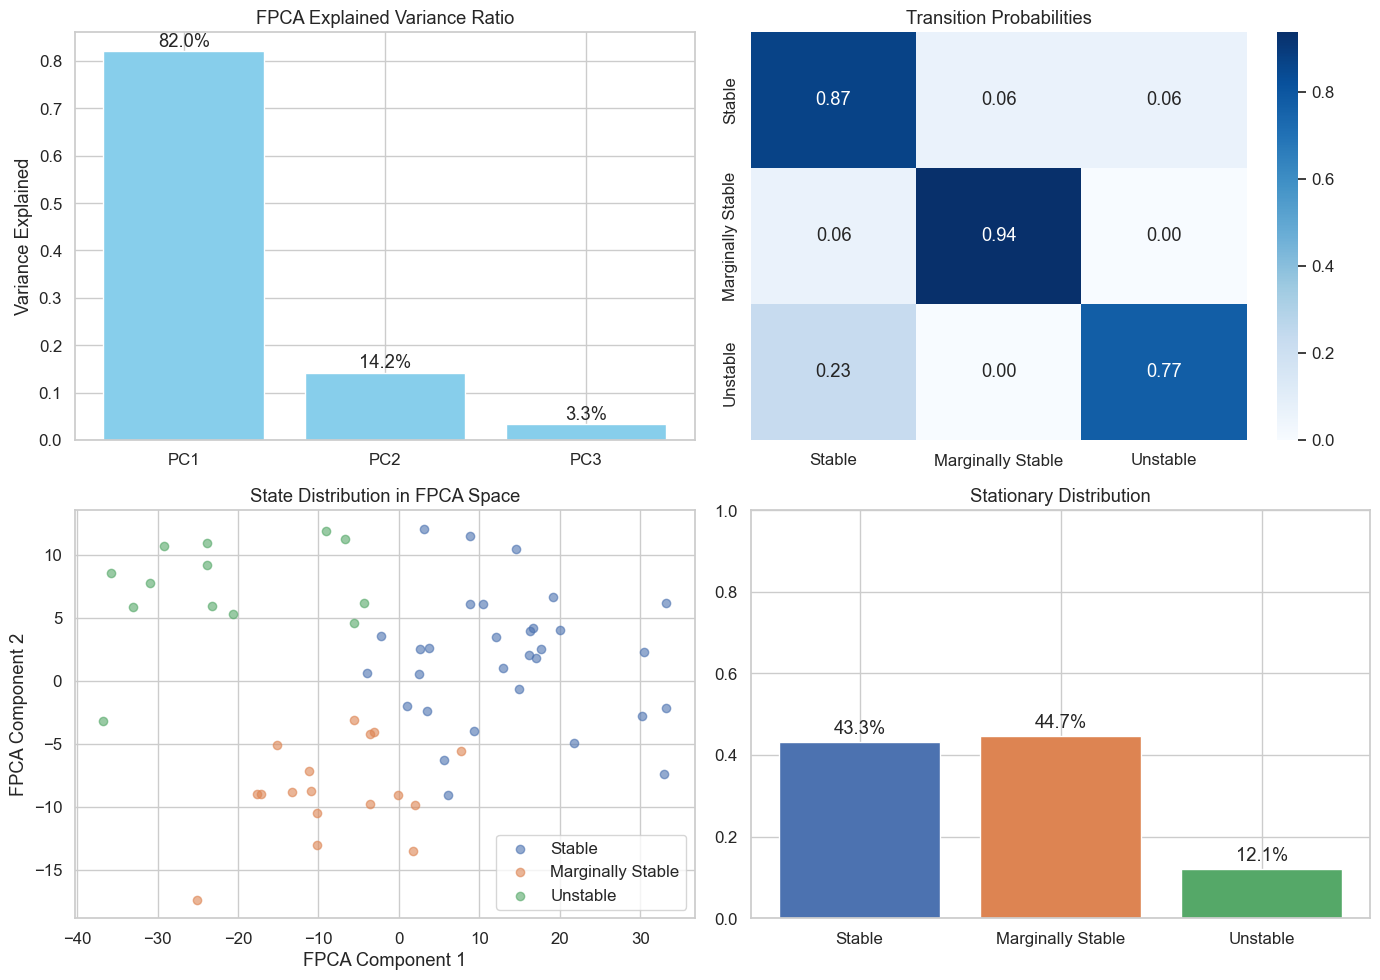

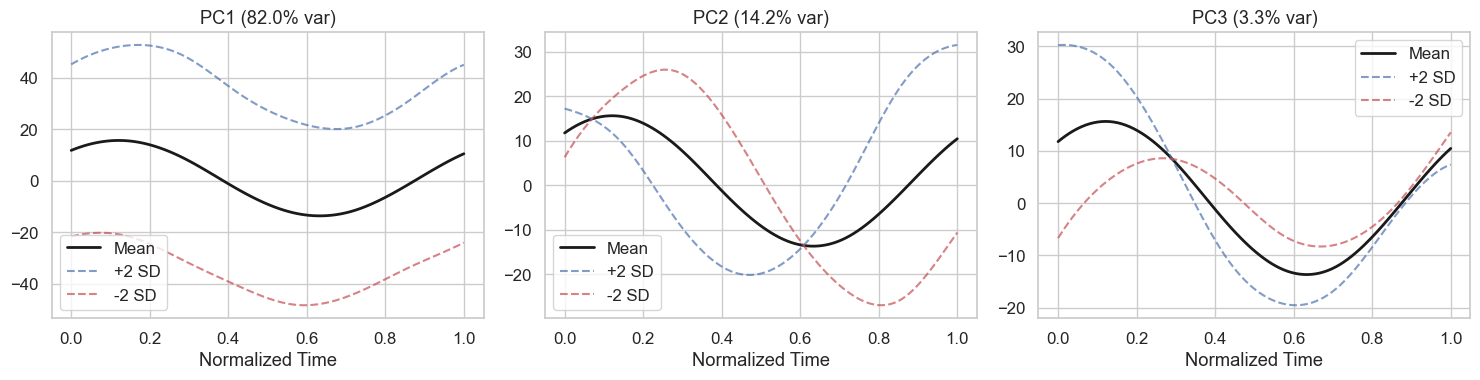

C:\Users\Natascha\AppData\Local\Temp\ipykernel_31580\2406565365.py:192: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(center_x, center_y, s=200, c=colors[i],


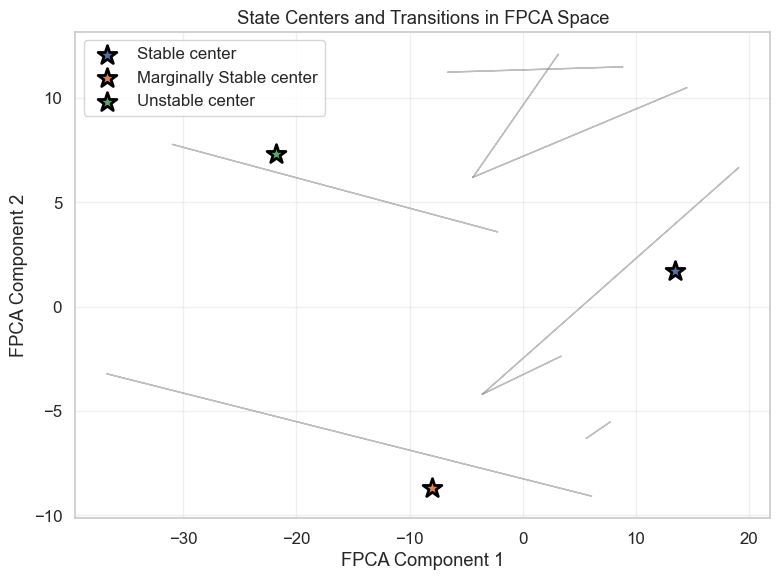

In [7]:
from preprocessing import preprocess_signal, _butter_filter
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import signal
from scipy.stats import gaussian_kde
def main():
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4"/ "markers.nc"
    events_file = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) Load & preprocess COM-z
    ds = xr.open_dataset(marker_file)
    da = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts = preprocess_signal(raw, fs)
    
    # 2) Find strikes & single-stride length
    ev_ds = xr.open_dataset(events_file)
    ev_da = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    avg_stride = np.mean(np.diff(strikes))
    win_samps = int(round(avg_stride * fs))
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) Build & run FPCA-MSM
    msm = FPCA_MSM("04_PWS", 
                   n_states=3,
                   window_size=win_samps,
                   window_overlap=0.0,
                   n_components=3,
                   n_basis=10)
    
    # Fit the model
    msm.fit(ts, fs)
    df = msm.metrics_history
    states = df['state'].values
    
    # Get colors and labels
    colors = sns.color_palette(n_colors=3)
    cmap = {i: colors[i] for i in range(3)}
    
    # 1) Overlaid kernel-density estimates (KDEs)
    plt.figure(figsize=(8, 4))
    for st, label in msm.state_labels.items():
        # Gather all samples in windows of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(df.loc[i, 'time'] * fs) : int(df.loc[i, 'time'] * fs) + win_samps]
            for i in idxs if int(df.loc[i, 'time'] * fs) + win_samps <= len(ts)
        ])
        # Compute & plot KDE
        if len(data) > 0:
            kde = gaussian_kde(data)
            xs = np.linspace(data.min(), data.max(), 200)
            plt.plot(xs, kde(xs),
                    color=colors[st],
                    label=label)
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State (FPCA-MSM)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2) Faceted histograms via Seaborn
    # Build a "long" DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st = int(row.state)
        start = int(row.time * fs)
        if start + win_samps <= len(ts):
            seg = ts[start: start + win_samps]
            long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value",
          stat="density", element="step", fill=True)
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State (FPCA-MSM)", y=1.02)
    plt.tight_layout()
    plt.show()

    # 3) FPCA scores trajectory plot
    plt.figure(figsize=(10, 6))
    if msm.n_components >= 2:
        # Plot trajectory in FPCA space
        plt.subplot(2, 1, 1)
        scatter = plt.scatter(df['fpca_0'], df['fpca_1'], 
                            c=df['state'], cmap='viridis', 
                            s=50, alpha=0.6)
        plt.plot(df['fpca_0'], df['fpca_1'], 'k-', alpha=0.3, linewidth=0.5)
        plt.xlabel('FPCA Component 1')
        plt.ylabel('FPCA Component 2')
        plt.title('Trajectory in FPCA Space')
        cbar = plt.colorbar(scatter)
        cbar.set_ticks([0, 1, 2])
        cbar.set_ticklabels(['Stable', 'Marginal', 'Unstable'])
        
        # Plot FPCA scores over time
        plt.subplot(2, 1, 2)
        for i in range(min(3, msm.n_components)):
            plt.plot(df['time'], df[f'fpca_{i}'], label=f'PC{i+1}')
        plt.xlabel('Time (s)')
        plt.ylabel('FPCA Score')
        plt.title('FPCA Scores Over Time')
        plt.legend()
    plt.tight_layout()
    plt.show()

    # 4) Per-stride functional curves colored by state
    plt.figure(figsize=(10, 4))
    grid = np.linspace(0, 1, win_samps)
    for idx, row in df.iterrows():
        if idx % 5 == 0:  # Plot every 5th window to avoid overcrowding
            st = int(row.state)
            start = int(row.time * fs)
            if start + win_samps <= len(ts):
                seg = ts[start:start + win_samps]
                plt.plot(grid, seg, color=cmap[st], alpha=0.3, linewidth=0.5)
    plt.title("Single-Stride Functional Curves by State")
    plt.xlabel("Normalized Time within Stride")
    plt.ylabel("Signal Value")
    plt.tight_layout()
    plt.show()

    # 5) Time series with S/M/U overlay
    letters = {0: "S", 1: "M", 2: "U"}
    dur = win_samps / fs
    times = np.arange(len(ts)) / fs
    plt.figure(figsize=(12, 4))
    plt.plot(times, ts, color='k', lw=1)
    for _, row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time + dur
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.2)
        plt.text((t0 + t1) / 2, ts.max() * 1.02, letters[st],
                ha='center', va='bottom', color=cmap[st], fontsize=12)
    plt.title("Time Series w/ Single-Stride States (FPCA-MSM)")
    plt.xlabel("Time (s)")
    plt.ylabel("COM-z")
    plt.ylim(ts.min(), ts.max() * 1.1)
    plt.tight_layout()
    plt.show()

    # 6) Compute and print metrics
    T = msm.transition_matrix
    pi = msm.stationary_dist
    tau = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    print("\n" + "="*50)
    print("FPCA-MSM RESULTS")
    print("="*50)
    print("\nTransition Matrix T:")
    print(np.round(T, 3))
    print("\nStationary Distribution Π:")
    print(np.round(pi, 3))
    print("\nMean Dwell Times τ (windows):")
    print(np.round(tau, 3))
    print("\nFraction of time in each state:")
    for key, value in summary.items():
        if 'frac_state' in key:
            print(f"  {key}: {value:.3f}")
    
    # Print FPCA-specific metrics
    if msm.fpca is not None:
        print("\nFPCA Explained Variance Ratio:")
        for i, var in enumerate(msm.fpca.explained_variance_ratio_):
            print(f"  PC{i+1}: {var:.1%}")
    
    # 7) Show built-in visualizations
    print("\nGenerating summary visualizations...")
    msm.visualize_patient_analysis()
    msm.visualize_functional_modes()
    
    # 8) Additional FPCA-specific plot: State transitions in FPCA space
    if msm.n_components >= 2:
        plt.figure(figsize=(8, 6))
        # Plot state centers
        for i, (state, label) in enumerate(msm.state_labels.items()):
            mask = df.state == state
            center_x = df.loc[mask, 'fpca_0'].mean()
            center_y = df.loc[mask, 'fpca_1'].mean()
            plt.scatter(center_x, center_y, s=200, c=colors[i], 
                       marker='*', edgecolors='black', linewidth=2,
                       label=f'{label} center')
        
        # Plot transitions
        for i in range(len(df) - 1):
            x0, y0 = df.iloc[i][['fpca_0', 'fpca_1']]
            x1, y1 = df.iloc[i+1][['fpca_0', 'fpca_1']]
            state0, state1 = df.iloc[i]['state'], df.iloc[i+1]['state']
            if state0 != state1:  # Only plot state transitions
                plt.arrow(x0, y0, x1-x0, y1-y0, 
                         head_width=0.05, head_length=0.05,
                         fc='gray', ec='gray', alpha=0.5)
        
        plt.xlabel('FPCA Component 1')
        plt.ylabel('FPCA Component 2')
        plt.title('State Centers and Transitions in FPCA Space')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()

## Model with stride time frames

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.linalg import eig
from scipy.interpolate import interp1d
from skfda import FDataGrid
from skfda.preprocessing.dim_reduction import FPCA
from skfda.representation.basis import BSpline
from typing import Optional, Dict, Tuple, List

sns.set_theme(style="whitegrid", font_scale=1.1)

class EventAlignedFPCA_MSM:
    """
    Event-aligned MSM for gait stability using FPCA + K-means:
    each stride (event-to-event) → functional representation → FPCA → K-means → Stable/Marginal/Unstable.
    """
    def __init__(self,
                 patient_id: str,
                 n_states: int = 3,
                 n_grid_points: int = 100,  # Number of points to interpolate each stride to
                 n_components: int = 3,
                 n_basis: int = 15):
        self.patient_id        = patient_id
        self.n_states          = n_states
        self.n_grid_points     = n_grid_points  # For interpolation
        self.n_components      = n_components
        self.n_basis           = n_basis
        self.scaler            = StandardScaler()
        self.metadata          = {}
        self.fpca              = None
        self.kmeans            = None
        self.transition_matrix = None
        self.stationary_dist   = None
        self.state_labels      = {0:"Stable", 1:"Marginally Stable", 2:"Unstable"}
        self.metrics_history   = None
        self.fdata             = None
        self.fpca_scores       = None
        self.stride_info       = None  # Store stride timing information

    def compute_event_aligned_functional_data(self, signal: np.ndarray, events: np.ndarray, fs: float) -> FDataGrid:
        """
        Convert event-aligned segments into functional data objects.
        Each segment is from one event to the next (e.g., foot strike to foot strike).
        """
        # Collect stride segments
        segments = []
        stride_times = []
        stride_durations = []
        valid_strides = []
        
        for i in range(len(events) - 1):
            start_time = events[i]
            end_time = events[i + 1]
            start_idx = int(start_time * fs)
            end_idx = int(end_time * fs)
            
            # Check bounds
            if start_idx >= 0 and end_idx <= len(signal):
                segment = signal[start_idx:end_idx]
                
                # Skip very short or very long strides (outliers)
                stride_duration = end_time - start_time
                if 0.5 < stride_duration < 2.0:  # Reasonable stride duration range
                    segments.append(segment)
                    stride_times.append(start_time)
                    stride_durations.append(stride_duration)
                    valid_strides.append(i)
        
        # Interpolate all segments to common grid
        interpolated_segments = []
        common_grid = np.linspace(0, 1, self.n_grid_points)
        
        for segment in segments:
            # Create interpolation function
            original_grid = np.linspace(0, 1, len(segment))
            f = interp1d(original_grid, segment, kind='cubic', fill_value='extrapolate')
            
            # Interpolate to common grid
            interpolated_segment = f(common_grid)
            interpolated_segments.append(interpolated_segment)
        
        # Convert to FDataGrid
        self.fdata = FDataGrid(
            data_matrix=np.array(interpolated_segments),
            grid_points=common_grid
        )
        
        # Store metadata
        self.metrics_history = pd.DataFrame({
            'stride_idx': range(len(segments)),
            'original_event_idx': valid_strides,
            'time': stride_times,
            'duration': stride_durations
        })
        
        # Store stride info for later use
        self.stride_info = {
            'events': events,
            'valid_strides': valid_strides,
            'fs': fs
        }
        
        print(f"Created functional data from {len(segments)} valid strides")
        print(f"Average stride duration: {np.mean(stride_durations):.3f}s ± {np.std(stride_durations):.3f}s")
        
        return self.fdata

    def apply_fpca(self) -> np.ndarray:
        """Apply Functional PCA to extract principal components."""
        try:
            # Try to smooth the functional data using B-spline basis
            basis = BSpline(n_basis=self.n_basis, domain_range=(0, 1))
            smooth_fdata = self.fdata.to_basis(basis)
            
            # Apply FPCA to smoothed data
            self.fpca = FPCA(n_components=self.n_components)
            self.fpca_scores = self.fpca.fit_transform(smooth_fdata)
        except:
            # If smoothing fails, apply FPCA directly to the discrete data
            print("Note: B-spline smoothing failed, using direct FPCA on discrete data")
            self.fpca = FPCA(n_components=self.n_components)
            self.fpca_scores = self.fpca.fit_transform(self.fdata)
        
        # Add FPCA scores to metrics history
        for i in range(self.n_components):
            self.metrics_history[f'fpca_{i}'] = self.fpca_scores[:, i]
        
        return self.fpca_scores

    def identify_stability_states(self) -> np.ndarray:
        """Apply K-means clustering to FPCA scores to identify states."""
        # Standardize FPCA scores
        X = self.scaler.fit_transform(self.fpca_scores)
        
        # Apply K-means
        self.kmeans = KMeans(n_clusters=self.n_states, random_state=42)
        raw_states = self.kmeans.fit_predict(X)
        
        # Order states by distance from origin (stability proxy)
        cluster_centers = self.kmeans.cluster_centers_
        norms = np.linalg.norm(cluster_centers, axis=1)
        order = np.argsort(norms)
        
        # Remap states to ensure 0=stable, 2=unstable
        state_mapping = {old: new for new, old in enumerate(order)}
        states = np.array([state_mapping[s] for s in raw_states])
        
        self.metrics_history['state'] = states
        return states

    def compute_transition_matrix(self, states: np.ndarray) -> np.ndarray:
        """Compute state transition probabilities."""
        T = np.zeros((self.n_states, self.n_states))
        for a, b in zip(states[:-1], states[1:]):
            T[a, b] += 1
        
        # Normalize rows
        row_sums = T.sum(axis=1)
        row_sums[row_sums == 0] = 1
        T = T / row_sums[:, None]
        
        self.transition_matrix = T
        return T

    def compute_stationary_distribution(self) -> np.ndarray:
        """Compute stationary distribution of the Markov chain."""
        vals, vecs = eig(self.transition_matrix.T)
        idx = np.argmin(np.abs(vals - 1))
        pi = np.real(vecs[:, idx])
        pi = pi / pi.sum()
        self.stationary_dist = np.abs(pi)
        return self.stationary_dist

    def compute_mean_dwell_times(self) -> np.ndarray:
        """Compute mean dwell time in each state."""
        τ = np.zeros(self.n_states)
        for i in range(self.n_states):
            p = self.transition_matrix[i, i]
            τ[i] = np.inf if p >= 1 else 1 / (1 - p)
        return τ

    def compute_stability_metrics(self) -> dict:
        """Compute overall stability metrics."""
        df = self.metrics_history
        out = {'patient_id': self.patient_id}
        
        # State fractions
        for i in range(self.n_states):
            out[f'frac_state_{i}'] = (df.state == i).mean()
        
        # Mean FPCA scores per state
        for i in range(self.n_states):
            state_data = df[df.state == i]
            for j in range(self.n_components):
                out[f'mean_fpca_{j}_state_{i}'] = state_data[f'fpca_{j}'].mean()
        
        # Mean stride duration per state
        for i in range(self.n_states):
            state_data = df[df.state == i]
            out[f'mean_duration_state_{i}'] = state_data['duration'].mean()
        
        return out

    def visualize_patient_analysis(self):
        """2×2 summary figure with FPCA results and transitions."""
        df = self.metrics_history.copy()
        names = list(self.state_labels.values())
        colors = sns.color_palette(n_colors=self.n_states)
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # 1) FPCA explained variance
        if self.fpca is not None and hasattr(self.fpca, 'explained_variance_ratio_'):
            explained_var = self.fpca.explained_variance_ratio_
            pc_labels = [f'PC{i+1}' for i in range(len(explained_var))]
            axes[0, 0].bar(pc_labels, explained_var, color='skyblue')
            axes[0, 0].set_title('FPCA Explained Variance Ratio')
            axes[0, 0].set_ylabel('Variance Explained')
            for i, v in enumerate(explained_var):
                axes[0, 0].text(i, v + 0.01, f'{v:.1%}', ha='center')
        
        # 2) Transition matrix heatmap
        sns.heatmap(self.transition_matrix,
                    annot=True, fmt=".2f",
                    xticklabels=names, yticklabels=names,
                    cmap="Blues", ax=axes[0, 1])
        axes[0, 1].set_title("Transition Probabilities")
        
        # 3) FPCA scores scatter (first 2 PCs)
        if self.n_components >= 2 and 'fpca_0' in df.columns and 'fpca_1' in df.columns:
            for i, (state, name) in enumerate(self.state_labels.items()):
                mask = df.state == state
                axes[1, 0].scatter(df.loc[mask, 'fpca_0'], 
                                 df.loc[mask, 'fpca_1'],
                                 label=name, color=colors[i], alpha=0.6)
            axes[1, 0].set_xlabel('FPCA Component 1')
            axes[1, 0].set_ylabel('FPCA Component 2')
            axes[1, 0].set_title('State Distribution in FPCA Space')
            axes[1, 0].legend()
        
        # 4) Stride duration by state
        # More informative than stationary distribution for event-aligned data
        duration_data = []
        for state, name in self.state_labels.items():
            durations = df[df.state == state]['duration'].values
            duration_data.extend([{'State': name, 'Duration': d} for d in durations])
        
        duration_df = pd.DataFrame(duration_data)
        sns.boxplot(data=duration_df, x='State', y='Duration', palette=colors, ax=axes[1, 1])
        axes[1, 1].set_title('Stride Duration by State')
        axes[1, 1].set_ylabel('Duration (s)')
        
        plt.tight_layout()
        plt.show()

    def visualize_functional_modes(self):
        """Visualize the functional principal components."""
        if self.fpca is None:
            return
        
        # Check if we have the necessary attributes
        if not hasattr(self.fpca, 'mean_') or not hasattr(self.fpca, 'components_'):
            print("FPCA components not available for visualization")
            return
        
        fig, axes = plt.subplots(1, min(3, self.n_components), 
                                figsize=(5*min(3, self.n_components), 4))
        
        if self.n_components == 1:
            axes = [axes]
        
        # Create evaluation grid
        grid = np.linspace(0, 1, 100)
        
        try:
            # Get mean function and components
            mean_func = self.fpca.mean_
            
            # Evaluate mean function on grid
            mean_values = mean_func(grid).flatten()
            
            for i in range(min(3, self.n_components)):
                # Get principal component
                pc = self.fpca.components_[i]
                pc_values = pc(grid).flatten()
                
                # Plot mean ± PC
                axes[i].plot(grid, mean_values, 'k-', 
                            label='Mean', linewidth=2)
                
                # Scale by explained variance if available
                if hasattr(self.fpca, 'explained_variance_'):
                    scale = np.sqrt(self.fpca.explained_variance_[i])
                else:
                    scale = 1.0
                    
                axes[i].plot(grid, mean_values + 2*scale*pc_values, 
                            'b--', label='+2 SD', alpha=0.7)
                axes[i].plot(grid, mean_values - 2*scale*pc_values, 
                            'r--', label='-2 SD', alpha=0.7)
                
                if hasattr(self.fpca, 'explained_variance_ratio_'):
                    axes[i].set_title(f'PC{i+1} ({self.fpca.explained_variance_ratio_[i]:.1%} var)')
                else:
                    axes[i].set_title(f'PC{i+1}')
                    
                axes[i].set_xlabel('Normalized Stride Time')
                axes[i].legend()
        except Exception as e:
            print(f"Error visualizing functional modes: {e}")
            for ax in axes:
                ax.text(0.5, 0.5, 'Functional modes\nnot available', 
                       ha='center', va='center', transform=ax.transAxes)
        
        plt.tight_layout()
        plt.show()

    def visualize_stride_alignment(self, signal: np.ndarray, max_strides: int = 20):
        """Visualize how strides are aligned and colored by state."""
        if self.stride_info is None:
            return
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
        
        colors = sns.color_palette(n_colors=self.n_states)
        events = self.stride_info['events']
        fs = self.stride_info['fs']
        
        # Plot 1: Original signal with event markers and state colors
        time_axis = np.arange(len(signal)) / fs
        ax1.plot(time_axis, signal, 'k-', alpha=0.5, linewidth=0.5)
        
        # Add stride coloring
        for idx, stride_idx in enumerate(self.stride_info['valid_strides'][:max_strides]):
            if stride_idx < len(events) - 1:
                start_time = events[stride_idx]
                end_time = events[stride_idx + 1]
                state = int(self.metrics_history.iloc[idx]['state'])  # Convert to int
                ax1.axvspan(start_time, end_time, color=colors[state], alpha=0.3)
        
        # Add event markers
        ax1.scatter(events, np.interp(events, time_axis, signal), 
                   color='red', s=50, zorder=5, label='Foot Strikes')
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Signal Value')
        ax1.set_title('Original Signal with Event-Aligned State Classification')
        ax1.legend()
        
        # Plot 2: Overlaid normalized strides colored by state
        grid = np.linspace(0, 1, self.n_grid_points)
        for i in range(min(max_strides, len(self.fdata))):
            state = int(self.metrics_history.iloc[i]['state'])  # Convert to int
            ax2.plot(grid, self.fdata[i].data_matrix[0], 
                    color=colors[state], alpha=0.5, linewidth=1)
        
        # Add mean curves per state
        for state, name in self.state_labels.items():
            state_mask = self.metrics_history['state'] == state
            if state_mask.sum() > 0:
                state_curves = self.fdata[state_mask].data_matrix
                mean_curve = np.mean(state_curves, axis=0)
                ax2.plot(grid, mean_curve, color=colors[state], 
                        linewidth=3, label=name)
        
        ax2.set_xlabel('Normalized Stride Time (0=strike, 1=next strike)')
        ax2.set_ylabel('Signal Value')
        ax2.set_title('Event-Aligned Strides by State')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

    def fit(self, signal: np.ndarray, events: np.ndarray, fs: float) -> 'EventAlignedFPCA_MSM':
        """
        Complete pipeline: signal + events → functional data → FPCA → clustering → MSM.
        
        Parameters:
        -----------
        signal : np.ndarray
            The time series signal (e.g., COM trajectory)
        events : np.ndarray
            Array of event times (e.g., foot strike times)
        fs : float
            Sampling frequency
        """
        print(f"Processing patient {self.patient_id} with event-aligned strides...")
        
        # 1. Create functional data from event-aligned segments
        print("Creating event-aligned functional data...")
        self.compute_event_aligned_functional_data(signal, events, fs)
        
        # 2. Apply FPCA
        print(f"Applying FPCA with {self.n_components} components...")
        self.apply_fpca()
        
        # 3. Identify states via K-means
        print("Identifying stability states via K-means...")
        states = self.identify_stability_states()
        
        # 4. Build Markov model
        print("Computing transition matrix...")
        self.compute_transition_matrix(states)
        
        # 5. Compute stationary distribution
        print("Computing stationary distribution...")
        self.compute_stationary_distribution()
        
        # 6. Compute metrics
        metrics = self.compute_stability_metrics()
        print(f"\nStability metrics for {self.patient_id}:")
        for key, value in metrics.items():
            if key != 'patient_id':
                print(f"  {key}: {value:.3f}")
        
        return self

Found 53 foot strikes
Time range: 10.34s to 69.33s
Processing patient 04_PWS with event-aligned strides...
Creating event-aligned functional data...
Created functional data from 52 valid strides
Average stride duration: 1.134s ± 0.022s
Applying FPCA with 3 components...
Identifying stability states via K-means...
Computing transition matrix...
Computing stationary distribution...

Stability metrics for 04_PWS:
  frac_state_0: 0.462
  frac_state_1: 0.327
  frac_state_2: 0.212
  mean_fpca_0_state_0: -7.561
  mean_fpca_1_state_0: -1.152
  mean_fpca_2_state_0: 0.817
  mean_fpca_0_state_1: 9.640
  mean_fpca_1_state_1: -2.594
  mean_fpca_2_state_1: -0.849
  mean_fpca_0_state_2: 1.598
  mean_fpca_1_state_2: 6.521
  mean_fpca_2_state_2: -0.471
  mean_duration_state_0: 1.145
  mean_duration_state_1: 1.121
  mean_duration_state_2: 1.134

Visualizing stride alignment...


C:\Users\Natascha\AppData\Local\Temp\ipykernel_31580\3842854932.py:116: DeprecationWarning: The BSpline class is deprecated. Use BSplineBasis instead.
  basis = BSpline(n_basis=self.n_basis, domain_range=(0, 1))


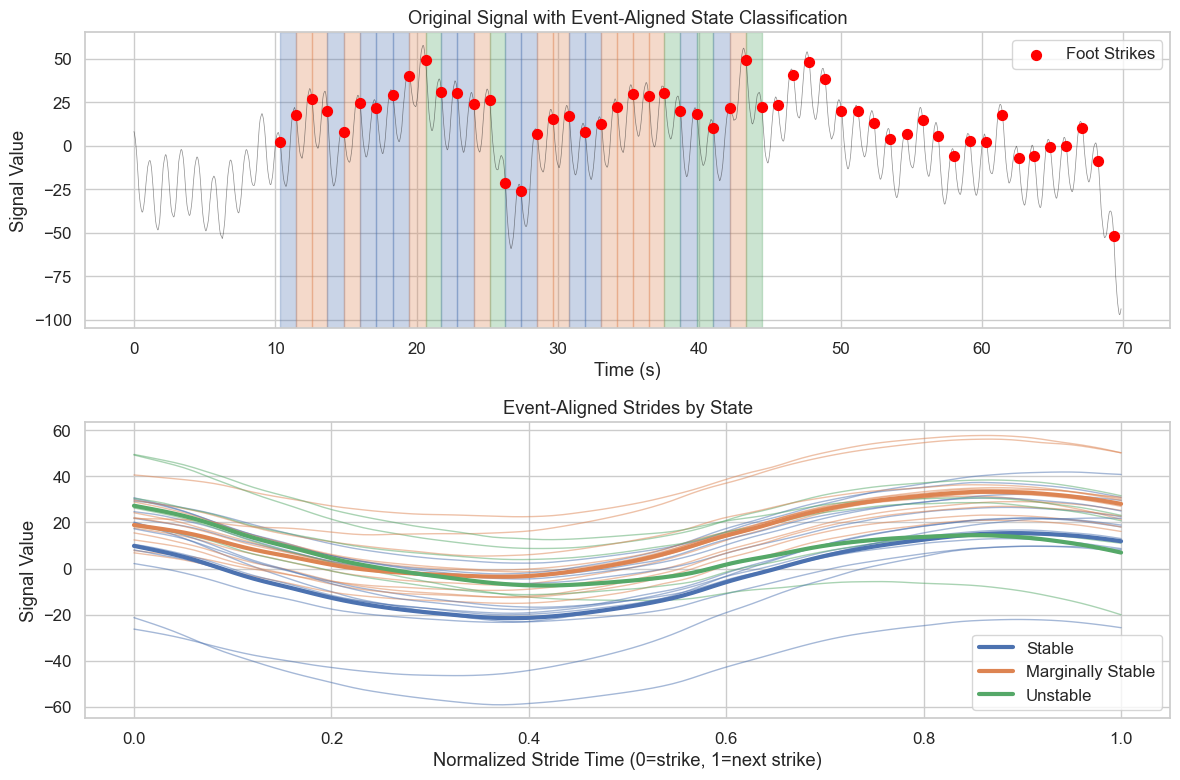

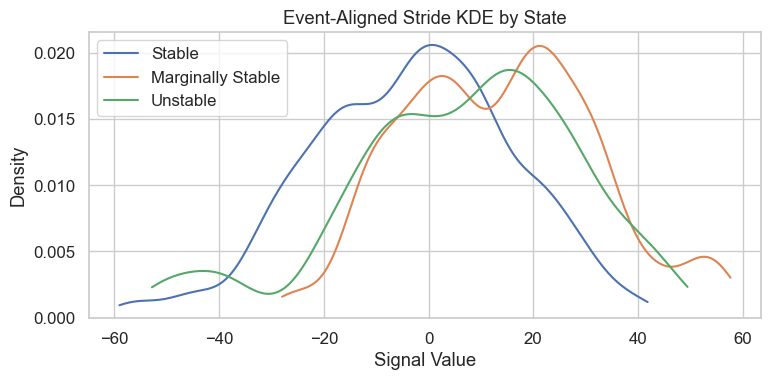

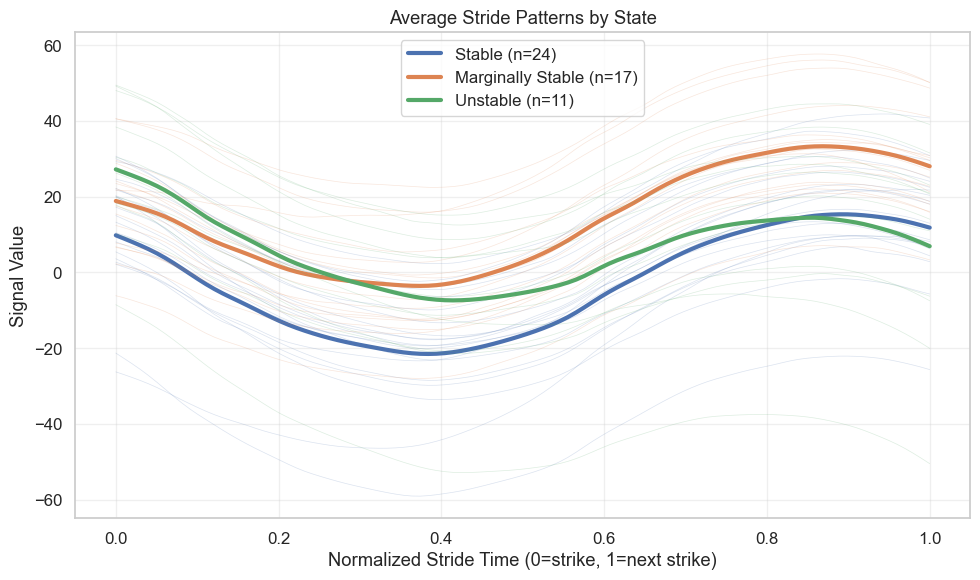

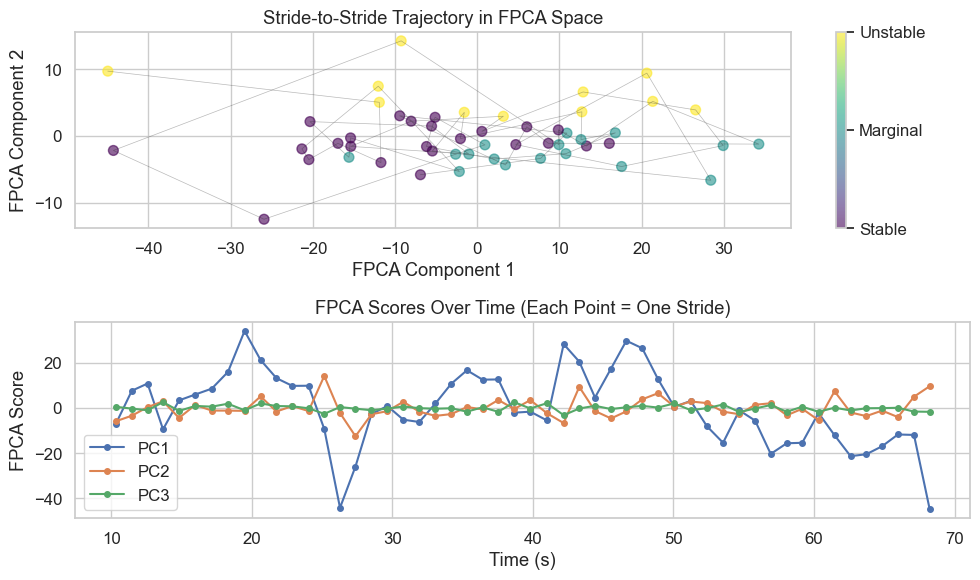

C:\Users\Natascha\AppData\Local\Temp\ipykernel_31580\794284042.py:155: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=duration_df, x='State', y='Duration', palette=colors)


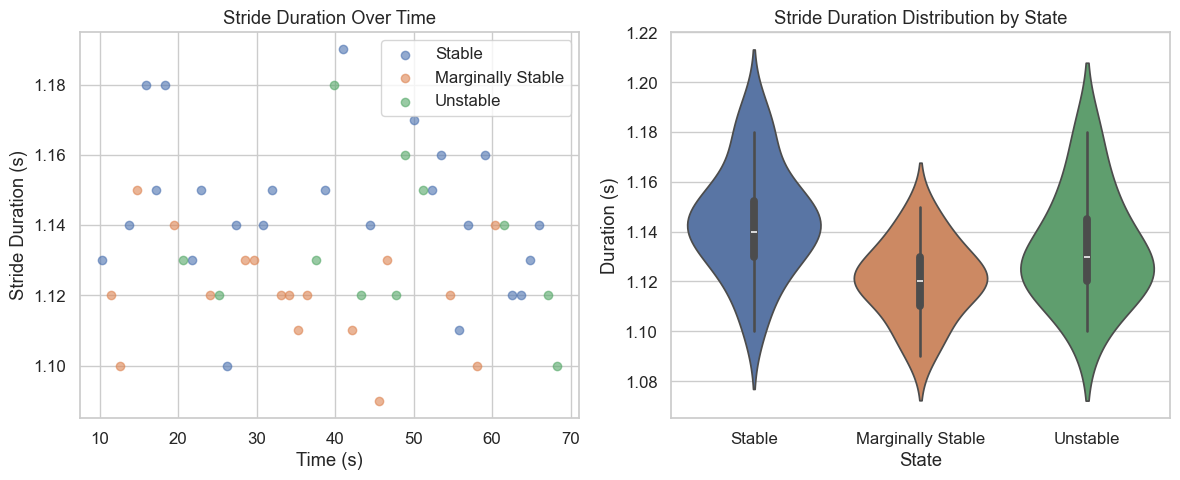

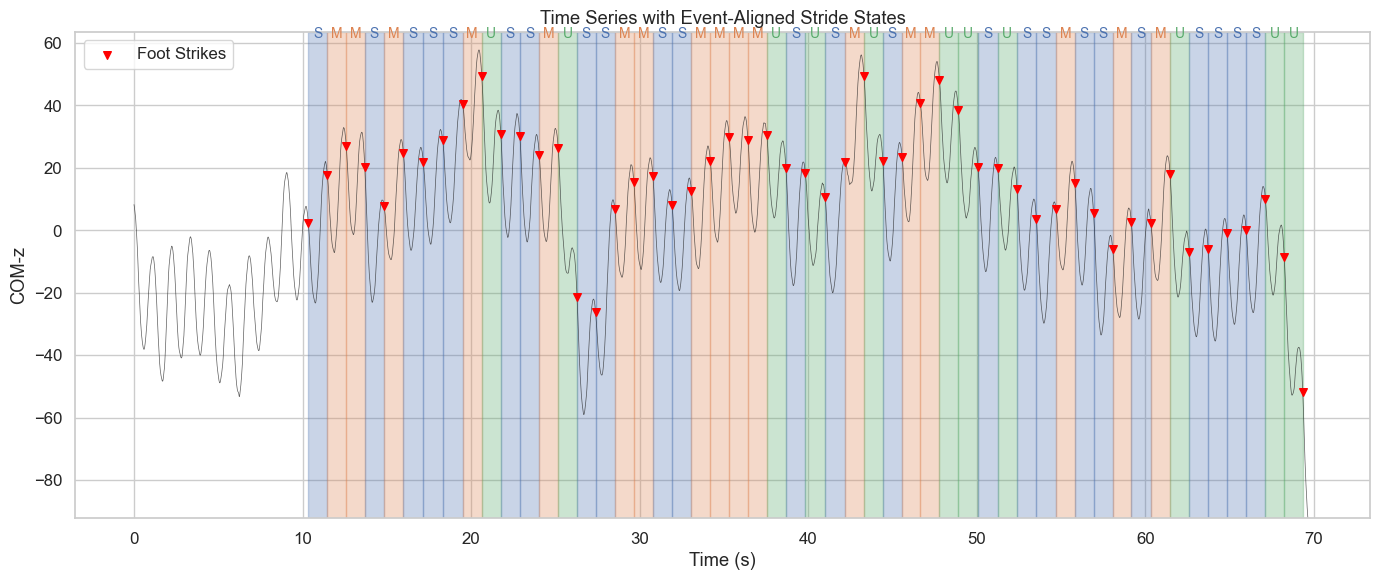


EVENT-ALIGNED FPCA-MSM RESULTS

Total strides analyzed: 52
Average stride duration: 1.134 ± 0.022s

Transition Matrix T:
[[0.417 0.458 0.125]
 [0.294 0.353 0.353]
 [0.8   0.    0.2  ]]

Stationary Distribution Π:
[0.459 0.325 0.215]

Mean Dwell Times τ (strides):
[1.714 1.545 1.25 ]

State Statistics:

Stable:
  Fraction of strides: 0.462
  Mean duration: 1.145s
  Duration std: 0.022s
  Mean PC1: -7.561
  Mean PC2: -1.152
  Mean PC3: 0.817

Marginally Stable:
  Fraction of strides: 0.327
  Mean duration: 1.121s
  Duration std: 0.016s
  Mean PC1: 9.640
  Mean PC2: -2.594
  Mean PC3: -0.849

Unstable:
  Fraction of strides: 0.212
  Mean duration: 1.134s
  Duration std: 0.022s
  Mean PC1: 1.598
  Mean PC2: 6.521
  Mean PC3: -0.471

FPCA Explained Variance Ratio:
  PC1: 92.7%
  PC2: 6.7%
  PC3: 0.5%

Generating summary visualizations...


C:\Users\Natascha\AppData\Local\Temp\ipykernel_31580\3842854932.py:253: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=duration_df, x='State', y='Duration', palette=colors, ax=axes[1, 1])


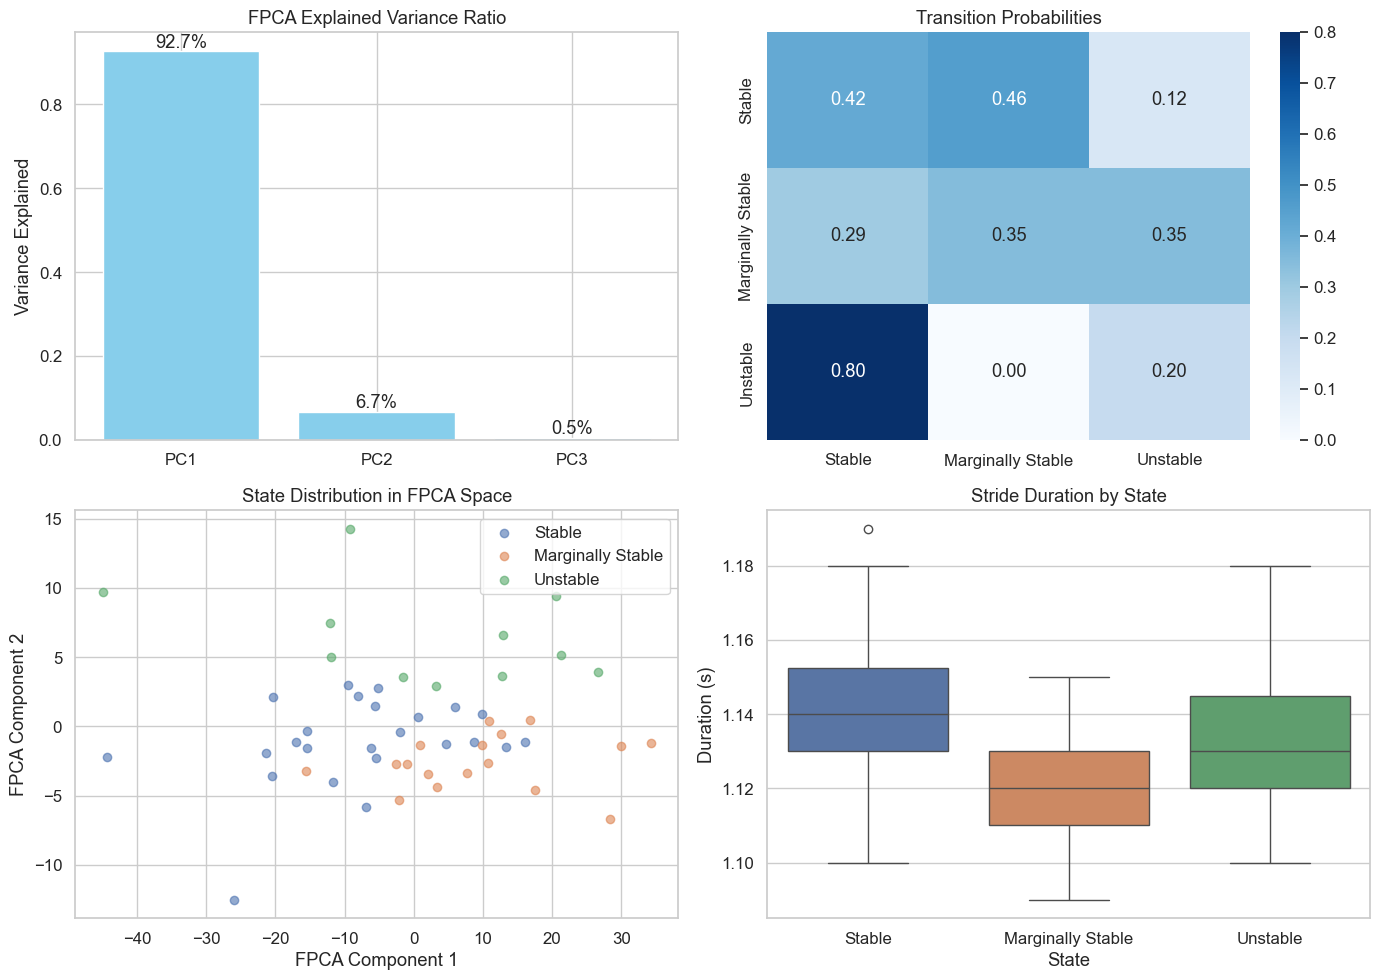

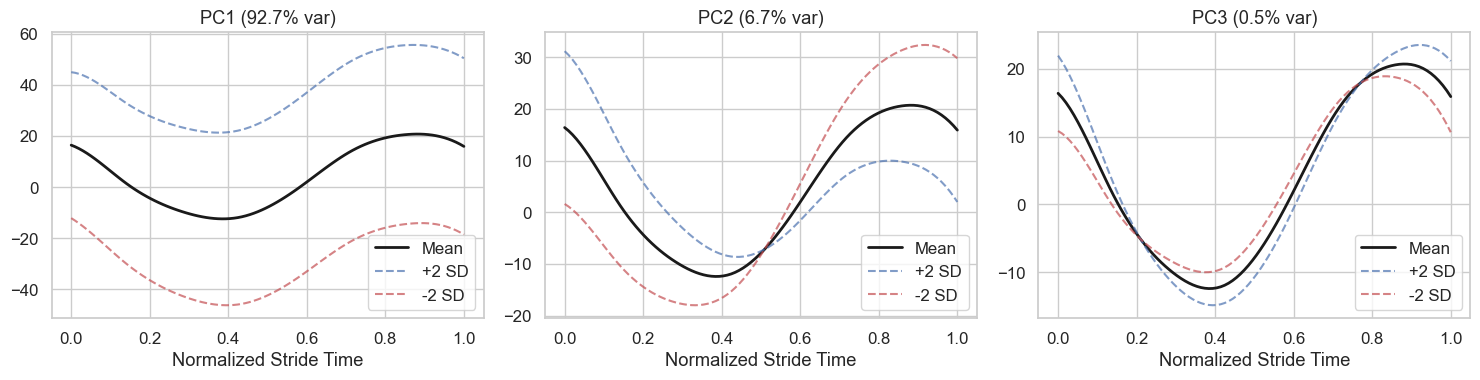


STATE SEQUENCE ANALYSIS

Found 34 state runs

Stable:
  Number of runs: 14
  Mean run length: 1.7 strides
  Max run length: 4 strides

Marginally Stable:
  Number of runs: 11
  Mean run length: 1.5 strides
  Max run length: 4 strides

Unstable:
  Number of runs: 9
  Mean run length: 1.2 strides
  Max run length: 2 strides


In [12]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import signal
from scipy.stats import gaussian_kde
# from EventAlignedFPCA_MSM import EventAlignedFPCA_MSM  # Import the event-aligned class



def main():
    cwd = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4"/ "markers.nc"
    events_file = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) Load & preprocess COM-z
    ds = xr.open_dataset(marker_file)
    da = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts = preprocess_signal(raw, fs)
    
    # 2) Extract foot strike events
    ev_ds = xr.open_dataset(events_file)
    ev_da = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev = ev_da.to_dataframe().reset_index()
    
    # Get right foot strikes (you could also use left or both)
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    print(f"Found {len(strikes)} foot strikes")
    print(f"Time range: {strikes[0]:.2f}s to {strikes[-1]:.2f}s")
    
    # 3) Build & run Event-Aligned FPCA-MSM
    msm = EventAlignedFPCA_MSM(
        patient_id="04_PWS", 
        n_states=3,
        n_grid_points=100,  # Interpolate each stride to 100 points
        n_components=3,
        n_basis=10
    )
    
    # Fit the model with events
    msm.fit(ts, strikes, fs)
    df = msm.metrics_history
    states = df['state'].values
    
    # Get colors and labels
    colors = sns.color_palette(n_colors=3)
    cmap = {i: colors[i] for i in range(3)}
    
    # 1) Show stride alignment visualization
    print("\nVisualizing stride alignment...")
    msm.visualize_stride_alignment(ts, max_strides=30)
    
    # 2) Overlaid kernel-density estimates (KDEs) - now truly stride-based
    plt.figure(figsize=(8, 4))
    for st, label in msm.state_labels.items():
        # Get all signal values from strides in this state
        state_mask = df['state'] == st
        state_strides = msm.fdata[state_mask]
        
        if len(state_strides) > 0:
            # Flatten all values from strides in this state
            all_values = state_strides.data_matrix.flatten()
            kde = gaussian_kde(all_values)
            xs = np.linspace(all_values.min(), all_values.max(), 200)
            plt.plot(xs, kde(xs), color=colors[st], label=label)
    
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Event-Aligned Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3) Average stride curves by state
    plt.figure(figsize=(10, 6))
    grid = np.linspace(0, 1, msm.n_grid_points)
    
    for state, name in msm.state_labels.items():
        state_mask = df['state'] == state
        if state_mask.sum() > 0:
            # Plot individual strides
            state_strides = msm.fdata[state_mask]
            for i in range(min(20, len(state_strides))):  # Plot up to 20 strides
                plt.plot(grid, state_strides[i].data_matrix[0], 
                        color=colors[state], alpha=0.2, linewidth=0.5)
            
            # Plot mean stride
            mean_stride = np.mean(state_strides.data_matrix, axis=0)
            plt.plot(grid, mean_stride, color=colors[state], 
                    linewidth=3, label=f'{name} (n={state_mask.sum()})')
    
    plt.xlabel("Normalized Stride Time (0=strike, 1=next strike)")
    plt.ylabel("Signal Value")
    plt.title("Average Stride Patterns by State")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 4) FPCA scores trajectory plot
    plt.figure(figsize=(10, 6))
    if msm.n_components >= 2:
        # Plot trajectory in FPCA space
        plt.subplot(2, 1, 1)
        scatter = plt.scatter(df['fpca_0'], df['fpca_1'], 
                            c=df['state'], cmap='viridis', 
                            s=50, alpha=0.6)
        plt.plot(df['fpca_0'], df['fpca_1'], 'k-', alpha=0.3, linewidth=0.5)
        plt.xlabel('FPCA Component 1')
        plt.ylabel('FPCA Component 2')
        plt.title('Stride-to-Stride Trajectory in FPCA Space')
        cbar = plt.colorbar(scatter)
        cbar.set_ticks([0, 1, 2])
        cbar.set_ticklabels(['Stable', 'Marginal', 'Unstable'])
        
        # Plot FPCA scores over time
        plt.subplot(2, 1, 2)
        for i in range(min(3, msm.n_components)):
            plt.plot(df['time'], df[f'fpca_{i}'], 'o-', label=f'PC{i+1}', markersize=4)
        plt.xlabel('Time (s)')
        plt.ylabel('FPCA Score')
        plt.title('FPCA Scores Over Time (Each Point = One Stride)')
        plt.legend()
    plt.tight_layout()
    plt.show()

    # 5) Stride duration analysis
    plt.figure(figsize=(12, 5))
    
    # Duration over time colored by state
    plt.subplot(1, 2, 1)
    for state in range(msm.n_states):
        mask = df['state'] == state
        plt.scatter(df.loc[mask, 'time'], df.loc[mask, 'duration'], 
                   color=colors[state], label=msm.state_labels[state], alpha=0.6)
    plt.xlabel('Time (s)')
    plt.ylabel('Stride Duration (s)')
    plt.title('Stride Duration Over Time')
    plt.legend()
    
    # Duration distribution by state
    plt.subplot(1, 2, 2)
    duration_data = []
    for state, name in msm.state_labels.items():
        durations = df[df.state == state]['duration'].values
        duration_data.extend([{'State': name, 'Duration': d} for d in durations])
    
    duration_df = pd.DataFrame(duration_data)
    sns.violinplot(data=duration_df, x='State', y='Duration', palette=colors)
    plt.title('Stride Duration Distribution by State')
    plt.ylabel('Duration (s)')
    plt.tight_layout()
    plt.show()

    # 6) Time series with stride-by-stride state labels
    plt.figure(figsize=(14, 6))
    times = np.arange(len(ts)) / fs
    plt.plot(times, ts, 'k-', linewidth=0.5, alpha=0.7)
    
    # Color each stride
    letters = {0: "S", 1: "M", 2: "U"}
    for idx in range(len(df)):
        stride_info = df.iloc[idx]
        event_idx = stride_info['original_event_idx']
        
        if pd.notnull(event_idx):
            event_idx = int(event_idx)
            if event_idx < len(strikes) - 1:
                start_time = strikes[event_idx]
                end_time = strikes[event_idx + 1]
                state = int(stride_info['state'])
                
                plt.axvspan(start_time, end_time, color=cmap[state], alpha=0.3)
                
                # Add state label at midpoint
                mid_time = (start_time + end_time) / 2
                plt.text(mid_time, ts.max() * 1.05, letters[state],
                        ha='center', va='bottom', color=cmap[state], fontsize=10)
        
    # Mark foot strikes
    plt.scatter(strikes, np.interp(strikes, times, ts), 
               color='red', s=30, zorder=5, marker='v', label='Foot Strikes')
    
    plt.title("Time Series with Event-Aligned Stride States")
    plt.xlabel("Time (s)")
    plt.ylabel("COM-z")
    plt.ylim(ts.min() * 0.95, ts.max() * 1.1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 7) Compute and print metrics
    T = msm.transition_matrix
    pi = msm.stationary_dist
    tau = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    print("\n" + "="*50)
    print("EVENT-ALIGNED FPCA-MSM RESULTS")
    print("="*50)
    print(f"\nTotal strides analyzed: {len(df)}")
    print(f"Average stride duration: {df['duration'].mean():.3f} ± {df['duration'].std():.3f}s")
    
    print("\nTransition Matrix T:")
    print(np.round(T, 3))
    print("\nStationary Distribution Π:")
    print(np.round(pi, 3))
    print("\nMean Dwell Times τ (strides):")
    print(np.round(tau, 3))
    
    print("\nState Statistics:")
    for i in range(msm.n_states):
        state_data = df[df['state'] == i]
        print(f"\n{msm.state_labels[i]}:")
        print(f"  Fraction of strides: {len(state_data)/len(df):.3f}")
        print(f"  Mean duration: {state_data['duration'].mean():.3f}s")
        print(f"  Duration std: {state_data['duration'].std():.3f}s")
        if msm.fpca is not None:
            for j in range(min(3, msm.n_components)):
                print(f"  Mean PC{j+1}: {state_data[f'fpca_{j}'].mean():.3f}")
    
    # Print FPCA-specific metrics
    if msm.fpca is not None and hasattr(msm.fpca, 'explained_variance_ratio_'):
        print("\nFPCA Explained Variance Ratio:")
        for i, var in enumerate(msm.fpca.explained_variance_ratio_):
            print(f"  PC{i+1}: {var:.1%}")
    
    # 8) Show built-in visualizations
    print("\nGenerating summary visualizations...")
    msm.visualize_patient_analysis()
    msm.visualize_functional_modes()
    
    # 9) State sequence analysis
    print("\n" + "="*50)
    print("STATE SEQUENCE ANALYSIS")
    print("="*50)
    
    # Find runs of consecutive states
    state_runs = []
    current_state = states[0]
    run_start = 0
    
    for i in range(1, len(states)):
        if states[i] != current_state:
            state_runs.append({
                'state': current_state,
                'start_idx': run_start,
                'end_idx': i-1,
                'length': i - run_start,
                'start_time': df.iloc[run_start]['time'],
                'end_time': df.iloc[i-1]['time']
            })
            current_state = states[i]
            run_start = i
    
    # Add final run
    state_runs.append({
        'state': current_state,
        'start_idx': run_start,
        'end_idx': len(states)-1,
        'length': len(states) - run_start,
        'start_time': df.iloc[run_start]['time'],
        'end_time': df.iloc[-1]['time']
    })
    
    # Analyze runs
    print(f"\nFound {len(state_runs)} state runs")
    for state in range(msm.n_states):
        runs = [r for r in state_runs if r['state'] == state]
        if runs:
            lengths = [r['length'] for r in runs]
            print(f"\n{msm.state_labels[state]}:")
            print(f"  Number of runs: {len(runs)}")
            print(f"  Mean run length: {np.mean(lengths):.1f} strides")
            print(f"  Max run length: {np.max(lengths)} strides")

if __name__ == "__main__":
    main()

Found 179 foot strikes
Time range: 11.96s to 287.53s
Processing patient 04_PWS with event-aligned strides...
Creating event-aligned functional data...
Created functional data from 167 valid strides
Average stride duration: 1.536s ± 0.083s
Applying FPCA with 3 components...
Identifying stability states via K-means...
Computing transition matrix...
Computing stationary distribution...

Stability metrics for 04_PWS:
  frac_state_0: 0.617
  frac_state_1: 0.186
  frac_state_2: 0.198
  mean_fpca_0_state_0: 2.429
  mean_fpca_1_state_0: -0.256
  mean_fpca_2_state_0: 4.382
  mean_fpca_0_state_1: 16.614
  mean_fpca_1_state_1: -3.783
  mean_fpca_2_state_1: -8.417
  mean_fpca_0_state_2: -23.187
  mean_fpca_1_state_2: 4.352
  mean_fpca_2_state_2: -5.772
  mean_duration_state_0: 1.536
  mean_duration_state_1: 1.485
  mean_duration_state_2: 1.581

Visualizing stride alignment...


C:\Users\Natascha\AppData\Local\Temp\ipykernel_31580\3842854932.py:116: DeprecationWarning: The BSpline class is deprecated. Use BSplineBasis instead.
  basis = BSpline(n_basis=self.n_basis, domain_range=(0, 1))


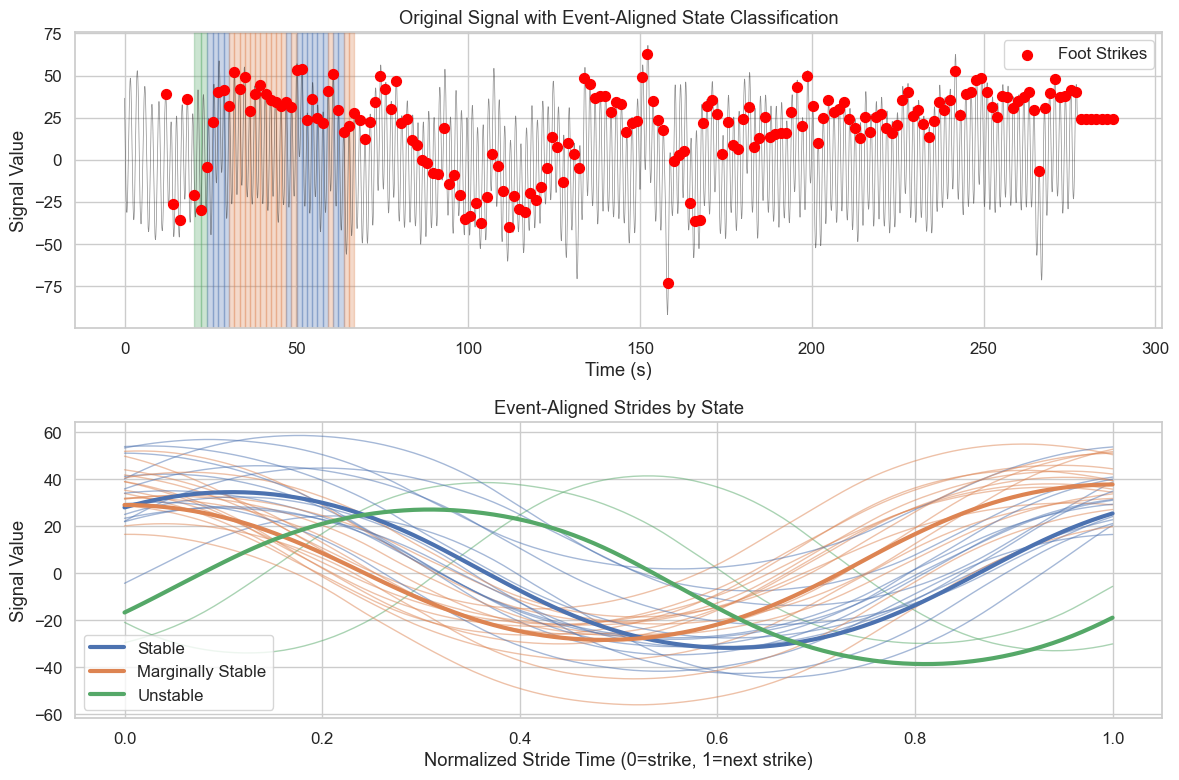

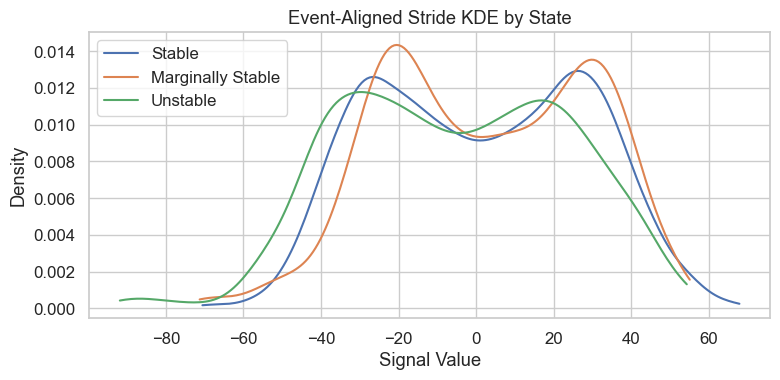

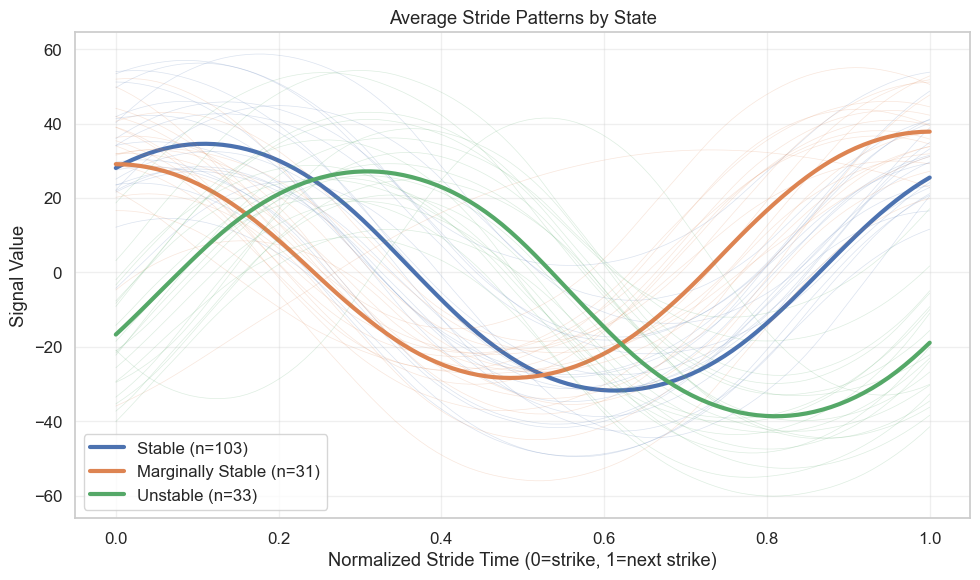

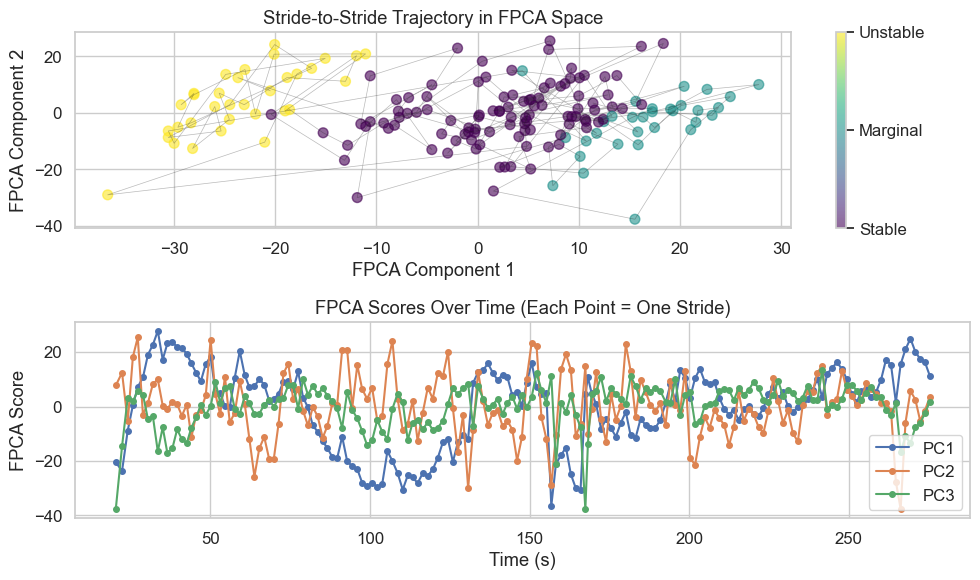

C:\Users\Natascha\AppData\Local\Temp\ipykernel_31580\1667897330.py:155: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=duration_df, x='State', y='Duration', palette=colors)


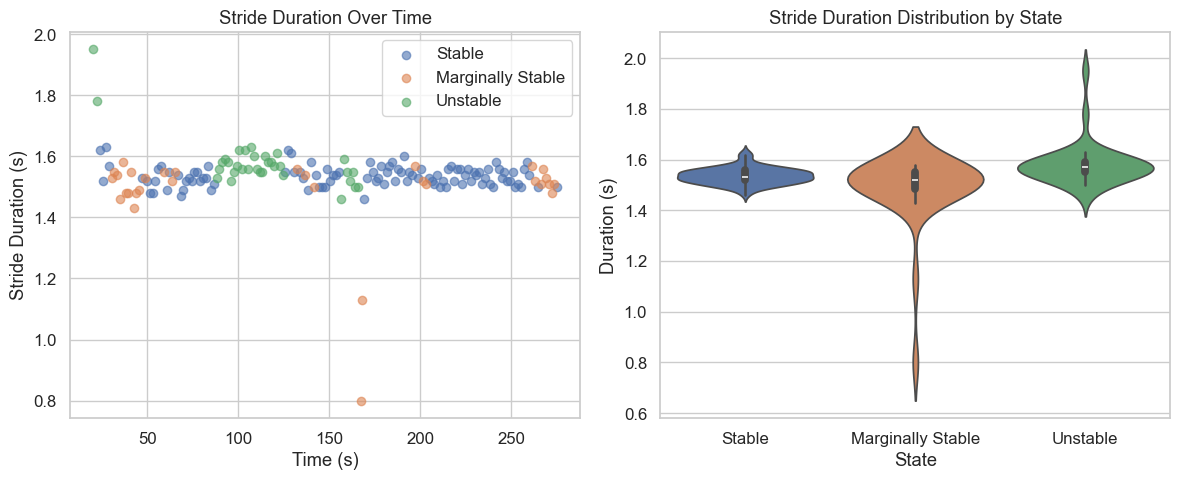

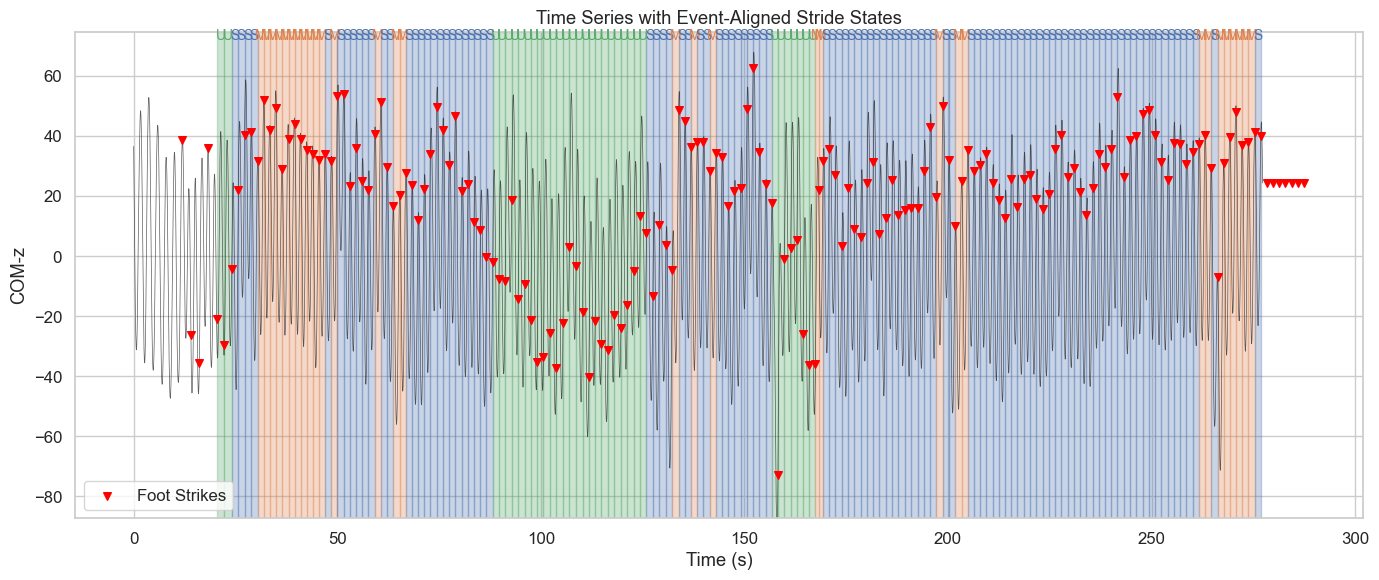


EVENT-ALIGNED FPCA-MSM RESULTS

Total strides analyzed: 167
Average stride duration: 1.536 ± 0.083s

Transition Matrix T:
[[0.873 0.108 0.02 ]
 [0.387 0.613 0.   ]
 [0.061 0.03  0.909]]

Stationary Distribution Π:
[0.662 0.196 0.143]

Mean Dwell Times τ (strides):
[ 7.846  2.583 11.   ]

State Statistics:

Stable:
  Fraction of strides: 0.617
  Mean duration: 1.536s
  Duration std: 0.032s
  Mean PC1: 2.429
  Mean PC2: -0.256
  Mean PC3: 4.382

Marginally Stable:
  Fraction of strides: 0.186
  Mean duration: 1.485s
  Duration std: 0.149s
  Mean PC1: 16.614
  Mean PC2: -3.783
  Mean PC3: -8.417

Unstable:
  Fraction of strides: 0.198
  Mean duration: 1.581s
  Duration std: 0.085s
  Mean PC1: -23.187
  Mean PC2: 4.352
  Mean PC3: -5.772

FPCA Explained Variance Ratio:
  PC1: 52.0%
  PC2: 30.3%
  PC3: 15.4%

Generating summary visualizations...


C:\Users\Natascha\AppData\Local\Temp\ipykernel_31580\3842854932.py:253: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=duration_df, x='State', y='Duration', palette=colors, ax=axes[1, 1])


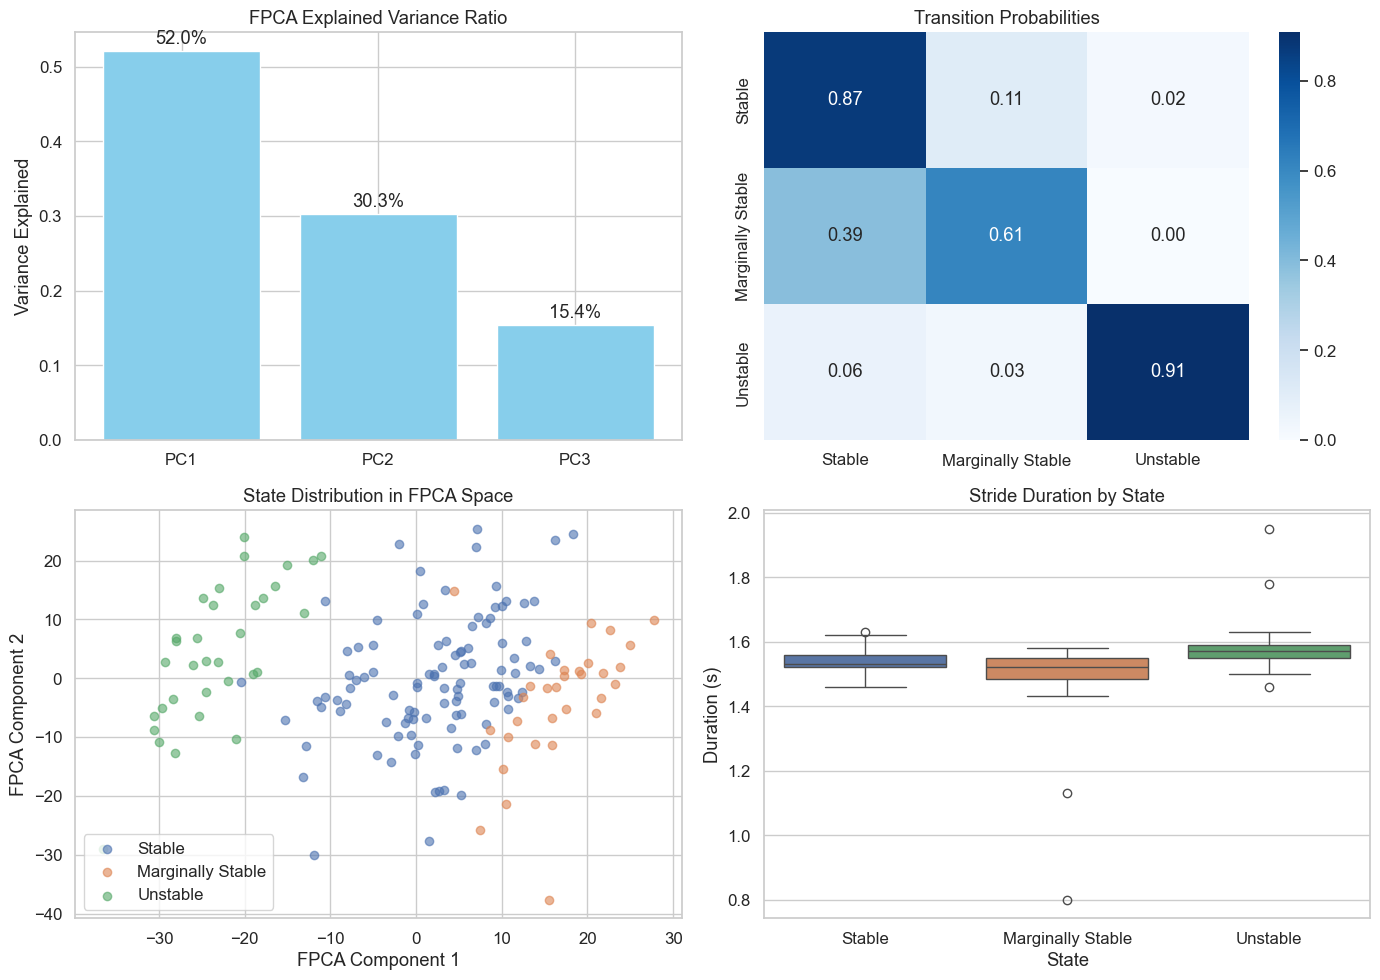

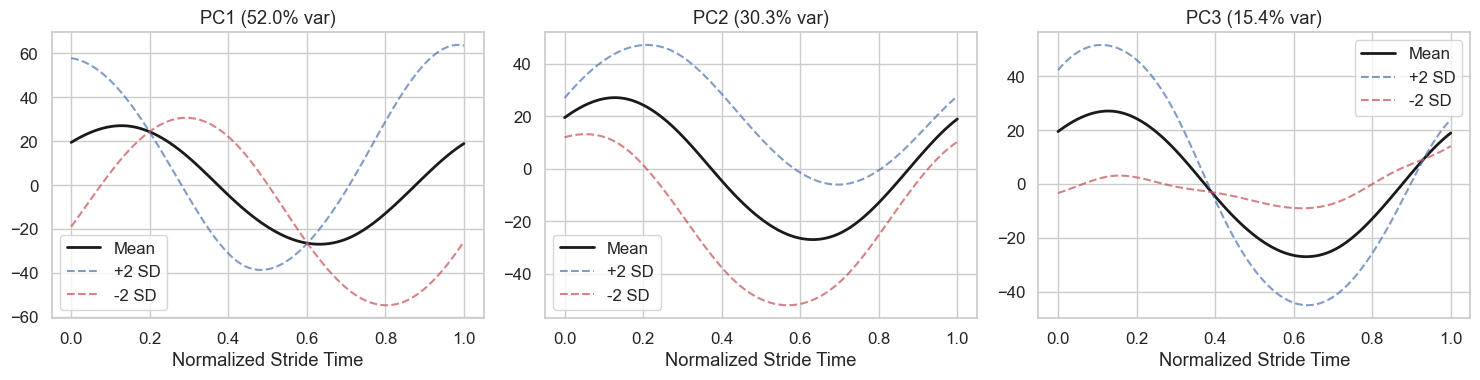


STATE SEQUENCE ANALYSIS

Found 29 state runs

Stable:
  Number of runs: 14
  Mean run length: 7.4 strides
  Max run length: 37 strides

Marginally Stable:
  Number of runs: 12
  Mean run length: 2.6 strides
  Max run length: 11 strides

Unstable:
  Number of runs: 3
  Mean run length: 11.0 strides
  Max run length: 24 strides


In [13]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import signal
from scipy.stats import gaussian_kde
# from EventAlignedFPCA_MSM import EventAlignedFPCA_MSM  # Import the event-aligned class



def main():
    cwd = Path.cwd()
    marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"events.nc"
    # marker_file = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4"/ "markers.nc"
    # events_file = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) Load & preprocess COM-z
    ds = xr.open_dataset(marker_file)
    da = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts = preprocess_signal(raw, fs)
    
    # 2) Extract foot strike events
    ev_ds = xr.open_dataset(events_file)
    ev_da = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev = ev_da.to_dataframe().reset_index()
    
    # Get right foot strikes (you could also use left or both)
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    print(f"Found {len(strikes)} foot strikes")
    print(f"Time range: {strikes[0]:.2f}s to {strikes[-1]:.2f}s")
    
    # 3) Build & run Event-Aligned FPCA-MSM
    msm = EventAlignedFPCA_MSM(
        patient_id="04_PWS", 
        n_states=3,
        n_grid_points=100,  # Interpolate each stride to 100 points
        n_components=3,
        n_basis=10
    )
    
    # Fit the model with events
    msm.fit(ts, strikes, fs)
    df = msm.metrics_history
    states = df['state'].values
    
    # Get colors and labels
    colors = sns.color_palette(n_colors=3)
    cmap = {i: colors[i] for i in range(3)}
    
    # 1) Show stride alignment visualization
    print("\nVisualizing stride alignment...")
    msm.visualize_stride_alignment(ts, max_strides=30)
    
    # 2) Overlaid kernel-density estimates (KDEs) - now truly stride-based
    plt.figure(figsize=(8, 4))
    for st, label in msm.state_labels.items():
        # Get all signal values from strides in this state
        state_mask = df['state'] == st
        state_strides = msm.fdata[state_mask]
        
        if len(state_strides) > 0:
            # Flatten all values from strides in this state
            all_values = state_strides.data_matrix.flatten()
            kde = gaussian_kde(all_values)
            xs = np.linspace(all_values.min(), all_values.max(), 200)
            plt.plot(xs, kde(xs), color=colors[st], label=label)
    
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Event-Aligned Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3) Average stride curves by state
    plt.figure(figsize=(10, 6))
    grid = np.linspace(0, 1, msm.n_grid_points)
    
    for state, name in msm.state_labels.items():
        state_mask = df['state'] == state
        if state_mask.sum() > 0:
            # Plot individual strides
            state_strides = msm.fdata[state_mask]
            for i in range(min(20, len(state_strides))):  # Plot up to 20 strides
                plt.plot(grid, state_strides[i].data_matrix[0], 
                        color=colors[state], alpha=0.2, linewidth=0.5)
            
            # Plot mean stride
            mean_stride = np.mean(state_strides.data_matrix, axis=0)
            plt.plot(grid, mean_stride, color=colors[state], 
                    linewidth=3, label=f'{name} (n={state_mask.sum()})')
    
    plt.xlabel("Normalized Stride Time (0=strike, 1=next strike)")
    plt.ylabel("Signal Value")
    plt.title("Average Stride Patterns by State")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 4) FPCA scores trajectory plot
    plt.figure(figsize=(10, 6))
    if msm.n_components >= 2:
        # Plot trajectory in FPCA space
        plt.subplot(2, 1, 1)
        scatter = plt.scatter(df['fpca_0'], df['fpca_1'], 
                            c=df['state'], cmap='viridis', 
                            s=50, alpha=0.6)
        plt.plot(df['fpca_0'], df['fpca_1'], 'k-', alpha=0.3, linewidth=0.5)
        plt.xlabel('FPCA Component 1')
        plt.ylabel('FPCA Component 2')
        plt.title('Stride-to-Stride Trajectory in FPCA Space')
        cbar = plt.colorbar(scatter)
        cbar.set_ticks([0, 1, 2])
        cbar.set_ticklabels(['Stable', 'Marginal', 'Unstable'])
        
        # Plot FPCA scores over time
        plt.subplot(2, 1, 2)
        for i in range(min(3, msm.n_components)):
            plt.plot(df['time'], df[f'fpca_{i}'], 'o-', label=f'PC{i+1}', markersize=4)
        plt.xlabel('Time (s)')
        plt.ylabel('FPCA Score')
        plt.title('FPCA Scores Over Time (Each Point = One Stride)')
        plt.legend()
    plt.tight_layout()
    plt.show()

    # 5) Stride duration analysis
    plt.figure(figsize=(12, 5))
    
    # Duration over time colored by state
    plt.subplot(1, 2, 1)
    for state in range(msm.n_states):
        mask = df['state'] == state
        plt.scatter(df.loc[mask, 'time'], df.loc[mask, 'duration'], 
                   color=colors[state], label=msm.state_labels[state], alpha=0.6)
    plt.xlabel('Time (s)')
    plt.ylabel('Stride Duration (s)')
    plt.title('Stride Duration Over Time')
    plt.legend()
    
    # Duration distribution by state
    plt.subplot(1, 2, 2)
    duration_data = []
    for state, name in msm.state_labels.items():
        durations = df[df.state == state]['duration'].values
        duration_data.extend([{'State': name, 'Duration': d} for d in durations])
    
    duration_df = pd.DataFrame(duration_data)
    sns.violinplot(data=duration_df, x='State', y='Duration', palette=colors)
    plt.title('Stride Duration Distribution by State')
    plt.ylabel('Duration (s)')
    plt.tight_layout()
    plt.show()

    # 6) Time series with stride-by-stride state labels
    plt.figure(figsize=(14, 6))
    times = np.arange(len(ts)) / fs
    plt.plot(times, ts, 'k-', linewidth=0.5, alpha=0.7)
    
    # Color each stride
    letters = {0: "S", 1: "M", 2: "U"}
    for idx in range(len(df)):
        stride_info = df.iloc[idx]
        event_idx = stride_info['original_event_idx']
        
        if pd.notnull(event_idx):
            event_idx = int(event_idx)
            if event_idx < len(strikes) - 1:
                start_time = strikes[event_idx]
                end_time = strikes[event_idx + 1]
                state = int(stride_info['state'])
                
                plt.axvspan(start_time, end_time, color=cmap[state], alpha=0.3)
                
                # Add state label at midpoint
                mid_time = (start_time + end_time) / 2
                plt.text(mid_time, ts.max() * 1.05, letters[state],
                        ha='center', va='bottom', color=cmap[state], fontsize=10)
        
    # Mark foot strikes
    plt.scatter(strikes, np.interp(strikes, times, ts), 
               color='red', s=30, zorder=5, marker='v', label='Foot Strikes')
    
    plt.title("Time Series with Event-Aligned Stride States")
    plt.xlabel("Time (s)")
    plt.ylabel("COM-z")
    plt.ylim(ts.min() * 0.95, ts.max() * 1.1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 7) Compute and print metrics
    T = msm.transition_matrix
    pi = msm.stationary_dist
    tau = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    print("\n" + "="*50)
    print("EVENT-ALIGNED FPCA-MSM RESULTS")
    print("="*50)
    print(f"\nTotal strides analyzed: {len(df)}")
    print(f"Average stride duration: {df['duration'].mean():.3f} ± {df['duration'].std():.3f}s")
    
    print("\nTransition Matrix T:")
    print(np.round(T, 3))
    print("\nStationary Distribution Π:")
    print(np.round(pi, 3))
    print("\nMean Dwell Times τ (strides):")
    print(np.round(tau, 3))
    
    print("\nState Statistics:")
    for i in range(msm.n_states):
        state_data = df[df['state'] == i]
        print(f"\n{msm.state_labels[i]}:")
        print(f"  Fraction of strides: {len(state_data)/len(df):.3f}")
        print(f"  Mean duration: {state_data['duration'].mean():.3f}s")
        print(f"  Duration std: {state_data['duration'].std():.3f}s")
        if msm.fpca is not None:
            for j in range(min(3, msm.n_components)):
                print(f"  Mean PC{j+1}: {state_data[f'fpca_{j}'].mean():.3f}")
    
    # Print FPCA-specific metrics
    if msm.fpca is not None and hasattr(msm.fpca, 'explained_variance_ratio_'):
        print("\nFPCA Explained Variance Ratio:")
        for i, var in enumerate(msm.fpca.explained_variance_ratio_):
            print(f"  PC{i+1}: {var:.1%}")
    
    # 8) Show built-in visualizations
    print("\nGenerating summary visualizations...")
    msm.visualize_patient_analysis()
    msm.visualize_functional_modes()
    
    # 9) State sequence analysis
    print("\n" + "="*50)
    print("STATE SEQUENCE ANALYSIS")
    print("="*50)
    
    # Find runs of consecutive states
    state_runs = []
    current_state = states[0]
    run_start = 0
    
    for i in range(1, len(states)):
        if states[i] != current_state:
            state_runs.append({
                'state': current_state,
                'start_idx': run_start,
                'end_idx': i-1,
                'length': i - run_start,
                'start_time': df.iloc[run_start]['time'],
                'end_time': df.iloc[i-1]['time']
            })
            current_state = states[i]
            run_start = i
    
    # Add final run
    state_runs.append({
        'state': current_state,
        'start_idx': run_start,
        'end_idx': len(states)-1,
        'length': len(states) - run_start,
        'start_time': df.iloc[run_start]['time'],
        'end_time': df.iloc[-1]['time']
    })
    
    # Analyze runs
    print(f"\nFound {len(state_runs)} state runs")
    for state in range(msm.n_states):
        runs = [r for r in state_runs if r['state'] == state]
        if runs:
            lengths = [r['length'] for r in runs]
            print(f"\n{msm.state_labels[state]}:")
            print(f"  Number of runs: {len(runs)}")
            print(f"  Mean run length: {np.mean(lengths):.1f} strides")
            print(f"  Max run length: {np.max(lengths)} strides")

if __name__ == "__main__":
    main()